# HPA Usage Mining
### Mineração de padrões de uso do Horizontal Pod Autoscaler em repositórios públicos do GitHub

## Objetivos e escopo

Este notebook implementa o pipeline de **mineração de dados** para um estudo de repositório de software (MSR) sobre o uso do **Horizontal Pod Autoscaler (HPA)** do Kubernetes em projetos hospedados no GitHub.

### O que o HPA faz

O HPA é o mecanismo nativo do Kubernetes para escalonamento horizontal automático de pods com base em métricas observadas. Uma definição HPA descreve: qual workload escalar (`scaleTargetRef`), entre quantos pods (`minReplicas` / `maxReplicas`), e com base em qual critério, CPU, memória, métricas externas ou de objetos Kubernetes. A versão da API usada (`autoscaling/v1`, `autoscaling/v2beta1`, `autoscaling/v2beta2`, `autoscaling/v2`) determina quais recursos estão disponíveis: v1 suporta apenas CPU via `targetCPUUtilizationPercentage`; v2 introduz múltiplos tipos de métrica, o bloco `behavior` para controle de cooldown e burst, e a possibilidade de combinar sinais de escalonamento

### Questões de pesquisa

O estudo é organizado em torno de **três questões de pesquisa formais**, cada uma correspondendo a um eixo analítico distinto:

**RQ1, Complexidade e métricas:** Qual é a complexidade das configurações HPA encontradas na prática, e quais métricas são mais comumente utilizadas para escalonamento?
Quantas features do hpa usa?


**RQ2, Atividade e manutenção:** Qual é a relação entre a atividade de um repositório de software e a manutenção de suas configurações HPA?

**RQ3, Evolução temporal:** Como a adoção das diferentes versões da API HPA (v1, v2beta1, v2beta2, v2) evoluiu ao longo do tempo em projetos de código aberto?

Cada RQ é investigada por meio de **perguntas** mais específicas, que guiam diretamente as análises e plots deste notebook:

| Pergunta | RQ | Análise |
|---|---|---|
| Qual a distribuição de versões de API HPA em uso? A migração para v2 está consolidada? | RQ3 | Análise 1 |
| Quais tipos de métricas são configurados? CPU continua dominando ou métricas customizadas têm adoção relevante? | RQ1 | Análise 2 |
| Como os parâmetros de réplicas (`minReplicas`, `maxReplicas`) se distribuem? Existem padrões recorrentes? | RQ1 | Análise 3 |
| Com que frequência repositórios ativos mantêm arquivos HPA que não são modificados há anos? | RQ2 | Análise 4 |
| O bloco `behavior` (introduzido em v2beta2) tem adoção real ou é raramente utilizado? | RQ1 | Análise 5 |
| Os valores de target configurados seguem práticas recomendadas ou defaults não calibrados? | RQ1 | Análise 6 |

### Pipeline de coleta

O pipeline é dividido em fases sequenciais. Cada fase persiste resultados em CSV para permitir retomada sem refazer chamadas de API (que são inteiramente cacheadas em disco). Este design é motivado pelo custo de API, a coleta completa exige ~25.000 chamadas à GitHub API e levaria horas sem cache.

| Fase | Entrada | Saída | O que faz |
|---|---|---|---|
| **Phase 1** | GitHub Code Search API | `phase1_latest.csv` | Descobre arquivos YAML com HPAs via queries shardizadas (~46 shards × 1.000 resultados) |
| **Phase 2** | Phase 1 | parciais phase2 | Coleta metadados de repositório (estrelas, datas) via GraphQL batch (50 repos/chamada) |
| **Phase 3** | Phase 1 | `phase3_latest.csv` | Baixa e faz parse dos arquivos, extrai `apiVersion`, detecta e exclui Helm templates |
| **Phase 3.5** | Phase 3 | `phase3_file_commits_latest.csv` | Coleta a data real do último commit de cada arquivo HPA (1 chamada/arquivo) |
| **Phase 4** | Phase 3 | `phase4_latest.csv` | Extrai métricas (tipo, nome, target), réplicas e presença de `behavior` |
| **Phase 5** | Phases 2 + 4 + 3.5 | `hpa_repo_aggregated.csv` | Join final, deriva `last_commit_age_years`, `is_active`, `is_outdated` |
| **Phase 6** | Phase 5 + Phase 3.5 | `phase6_commit_timeline_latest.csv` | Coleta série temporal de commits (repo e arquivo HPA) para amostra estratificada |

### Decisões de projeto

**Shards na Phase 1:** o endpoint `/search/code` retorna no máximo 1.000 resultados por query. Para ampliar a cobertura, usam-se queries diversificadas por tipo de declaração, versão de API, nome de arquivo, path, topic e organização. Duplicatas entre shards são removidas por `(repo_full_name, path)`.

**Exclusão de Helm templates:** arquivos Helm contêm `{{ .Values.hpa.minReplicas }}` em vez de valores reais. Incluí-los produziria NaN em todas as métricas numéricas e distorceria a análise de configurações. A exclusão ocorre em dois níveis: (1) shards da Phase 1 não incluem `path:templates`; (2) a Phase 3 detecta templates por presença de `{{` e pelo caminho do arquivo.

**`file_last_commit` em vez de `pushed_at`:** `pushed_at` é atualizado por qualquer commit no repositório inteiro. Para distinguir "repositório ativo que também mantém seu HPA" de "repositório ativo cujo HPA está congelado", é necessário a data do commit do arquivo HPA especificamente, coletada na Phase 3.5.

**Phase 6 como amostra:** coletar histórico completo de commits para todos os ~14.000 repositórios exigiria >140.000 chamadas de API. Por isso, a Phase 6 opera sobre uma amostra estratificada por status de atividade, o que reduz o custo enquanto mantém representatividade dos três estratos (active, in-between, outdated).

## 1. Configuração do ambiente

O token do GitHub (`GITHUB_TOKEN`) é obrigatório para todos os endpoints autenticados.  
Sem autenticação, o rate limit cai de 5.000 para 60 chamadas por hora, insuficiente para qualquer das fases.

Configure o token no arquivo `.env` antes de executar qualquer célula:

```
GITHUB_TOKEN="ghp_xxxxxxxxxxxxxxxxxxxx"
```

O token precisa ter o escopo `public_repo` (leitura de repositórios públicos). Nenhum escopo de escrita é necessário.

In [1]:
# ── Carrega token do arquivo .env ─────────────────────────────────────────
from pathlib import Path
import os
from dotenv import load_dotenv

# Garante que o arquivo .env existe (cria esqueleto se não existir)
_env = Path(".env")
if not _env.exists():
    _env.write_text('GITHUB_TOKEN=""\n', encoding="utf-8")
    print("Arquivo .env criado. Preencha GITHUB_TOKEN e reexecute.")

load_dotenv(".env")
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN", "").strip()

if not GITHUB_TOKEN:
    raise RuntimeError(
        "GITHUB_TOKEN não configurado.\n"
        "Edite o arquivo .env e adicione: GITHUB_TOKEN=\"ghp_...\"\n"
        "Depois reexecute esta célula."
    )
print(f"Token carregado  ({len(GITHUB_TOKEN)} caracteres).")

Token carregado  (40 caracteres).


## 2. Imports, logging, enumerações e constantes

Esta célula centraliza todas as dependências e define as estruturas de suporte usadas pelo pipeline:

- **`Col` (enum):** nomes canônicos de colunas CSV. Usar um enum em vez de strings literais evita erros de digitação e facilita refatoração quando o schema muda.
- **`LogEvent` e `Msg` (enums):** rótulos padronizados para logs, tornando os outputs estruturados e filtrável.
- **`DATA_DIR` / `PARTIAL_DIR`:** diretório de saída dos CSVs definitivos e dos checkpoints intermediários respectivamente. Separar os dois permite limpar checkpoints sem afetar os resultados finais.
- **`persist_df` / `persist_df_both`:** funções de persistência com timestamp no nome do arquivo. O timestamp permite rastrear quando cada fase foi executada e manter múltiplas execuções sem sobrescrever. `persist_df_both` grava adicionalmente um alias `*_latest.csv` sem timestamp, facilitando o acesso no notebook de análise.

In [2]:
import os, sys, time, json, math, re, queue, hashlib, functools, random, itertools, textwrap, logging
from enum import Enum
from typing import Optional, Dict, Any, List, Tuple, Iterable

import pandas as pd
import numpy as np

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import yaml
from yaml.loader import SafeLoader

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict, Counter

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# ── Logging ───────────────────────────────────────────────────────────────
class LogEvent(Enum):
    START              = "START"
    CACHE_HIT          = "CACHE_HIT"
    CACHE_MISS         = "CACHE_MISS"
    RATE_LIMIT_SLEEP   = "RATE_LIMIT_SLEEP"
    REQUEST            = "REQUEST"
    REQUEST_RETRY      = "REQUEST_RETRY"
    REQUEST_FAIL       = "REQUEST_FAIL"
    PARSE_YAML_FAIL    = "PARSE_YAML_FAIL"
    HELM_TEMPLATE      = "HELM_TEMPLATE_DETECTED"
    PERSIST            = "PERSIST"
    DONE               = "DONE"

def build_logger(name: str = "hpaa_usage"):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        ch = logging.StreamHandler(sys.stdout)
        ch.setFormatter(logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s"))
        logger.addHandler(ch)
    return logger

log = build_logger("hpaa_usage")

# ── Enumerações de colunas ─────────────────────────────────────────────────
class Col(Enum):
    OWNER        = "Owner"
    PROJECT      = "Project"
    FILE_PATH    = "File Path"
    HPA_COUNT    = "hpa_count"
    APIVERSION   = "apiVersion"
    IS_HELM      = "Is Helm Template"
    METRIC_NAME  = "Metric Name"
    METRIC_TYPE  = "Metric Type"
    TARGET_VALUE = "Target Value"
    HAS_BEHAVIOR = "Has Behavior"
    STARS        = "stargazers_count"
    CREATED_AT   = "created_at"
    PUSHED_AT    = "pushed_at"

class Msg(Enum):
    CACHED_HIT  = "Cache hit"
    CACHED_MISS = "Cache miss"

# ── Diretórios e helpers de persistência ───────────────────────────────────
DATA_DIR    = Path("data")
PARTIAL_DIR = DATA_DIR / "partial_results"
PLOTS_DIR       = Path('plots')
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

def persist_df(df: pd.DataFrame, tag: str) -> Path:
    ts  = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
    out = PARTIAL_DIR / f"{ts}-{tag}.csv"
    df.to_csv(out, index=False)
    log.info("%s - %s", LogEvent.PERSIST.value, out.as_posix())
    return out

def persist_df_both(df: pd.DataFrame, tag: str):
    """Grava CSV com timestamp e também alias fixo *_latest.csv em DATA_DIR."""
    out_ts = persist_df(df, tag)
    latest = DATA_DIR / f"{tag}_latest.csv"
    df.to_csv(latest, index=False)
    log.info("PERSIST latest alias: %s", latest.resolve())
    return out_ts, latest

def latest_csv(tag: str) -> Optional[Path]:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    return max(files, key=lambda p: p.stat().st_mtime) if files else None

def list_phase_csvs(tag: str):
    files = sorted(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    print(f"{len(files)} arquivo(s) '{tag}' em {PARTIAL_DIR}:")
    for p in files[-5:]:
        size_kb = p.stat().st_size / 1024
        print(f"  {p.name}  ({size_kb:.1f} KB)")
    alias = DATA_DIR / f"{tag}_latest.csv"
    if alias.exists():
        print(f"  alias: {alias.name}  ({alias.stat().st_size/1024:.1f} KB)")

def csv_has_columns(p: Path, required: list) -> bool:
    try:
        with p.open("r", encoding="utf-8") as fh:
            header = fh.readline().strip()
        return all(c in header.split(",") for c in required)
    except Exception:
        return False

# ── Helpers de conversão ───────────────────────────────────────────────────
def to_dt(s):
    return pd.to_datetime(s, errors="coerce", utc=True)

# ── Estilos de plot ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

VERSION_COLORS = {
    "v1":      "#E65100",
    "v2beta1": "#7B1FA2",
    "v2beta2": "#2E7D32",
    "v2":      "#1565C0",
    "other":   "#757575",
    "unknown": "#BDBDBD",
}

def map_version(api):
    if not isinstance(api, str): return "unknown"
    if "v2beta2" in api: return "v2beta2"
    if "v2beta1" in api: return "v2beta1"
    if "v2"      in api: return "v2"
    if "v1"      in api: return "v1"
    return "other"

# ── Salvar figura ──────────────────────────────────────────────────────────
def savefig(name):
    """Salva a figura atual em plots/ com resolução adequada para publicação."""
    path = PLOTS_DIR / name
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Salvo: {path}')

print("Setup concluído  —  DATA_DIR:", DATA_DIR.resolve())

Setup concluído  —  DATA_DIR: /home/calendario2009/Downloads/hpa_analysis_updated (1)/hpa_project_new/hpa_analysis/data


## 3. Cliente GitHub API

O cliente encapsula toda a comunicação com a GitHub REST API e oferece duas interfaces adicionais para uso nas fases do pipeline:

### REST com retry automático (`GitHubClient.get`)

Usa `requests.Session` com um adaptador `HTTPAdapter(Retry(...))` configurado para:
- Retentar automaticamente em erros transientes: 429 (rate limit), 500/502/503/504 (erros de servidor)
- Backoff exponencial entre tentativas (fator 1.2, até 5 tentativas)
- Pool de conexões com 64 slots para suportar execução concorrente sem criar uma sessão por thread

O método `_rate_limit_guard` lê os headers `X-RateLimit-Remaining` e `X-RateLimit-Reset` em cada resposta. Se o número de chamadas restantes cair para 1 ou menos, o cliente pausa automaticamente até o momento de reset, evitando erros 403.

### GraphQL batch (`GitHubClient.graphql_batch_repos`)

A Phase 2 precisa dos metadados de ~10.000 repositórios únicos. Fazer uma chamada REST por repositório (`GET /repos/{owner}/{repo}`) consumiria ~10.000 chamadas do rate limit de 5.000/hora, exigindo mais de 2 horas só para essa fase.

A solução é usar a **GitHub GraphQL API v4**, que permite buscar múltiplos repositórios em uma única requisição via aliases:

```graphql
{
  r0: repository(owner: "google", name: "gke-samples") { stargazerCount createdAt pushedAt }
  r1: repository(owner: "argoproj", name: "argo-cd")   { stargazerCount createdAt pushedAt }
  ...
}
```

O método `graphql_batch_repos` divide a lista de repositórios em lotes de até 50, executa cada lote como uma única chamada GraphQL e retorna os resultados consolidados. Para ~10.000 repositórios, isso reduz o número de chamadas de 10.000 para ~200, completando a Phase 2 em minutos em vez de horas.

O fallback para REST individual (`get_repo_details_rest`) é mantido para casos onde o GraphQL retorna nulo (repositório privado, deletado ou renomeado).

In [3]:
class GitHubClient:
    """
    Cliente para GitHub REST API v3 e GraphQL API v4.
    Gerencia autenticação, retry, rate-limit e pool de conexões.
    """
    GRAPHQL_URL = "https://api.github.com/graphql"

    def __init__(self, token: str, user_agent: str = "hpa-usage-miner"):
        self.base = "https://api.github.com"
        self.token = token
        self.session = requests.Session()
        retries = Retry(total=5, backoff_factor=1.2, status_forcelist=[429, 500, 502, 503, 504])
        adapter = HTTPAdapter(max_retries=retries, pool_connections=64, pool_maxsize=64)
        self.session.mount("https://", adapter)
        self.session.headers.update({
            "Authorization": f"token {token}",
            "Accept":        "application/vnd.github+json",
            "X-GitHub-Api-Version": "2022-11-28",
            "User-Agent":    user_agent,
        })

    def _rate_limit_guard(self, resp: requests.Response):
        remaining = int(resp.headers.get("X-RateLimit-Remaining", "10"))
        reset_ts  = int(resp.headers.get("X-RateLimit-Reset", "0"))
        if remaining <= 1:
            sleep_for = max(0, reset_ts - int(time.time())) + 3
            log.info("%s  sleeping %ss (remaining=%d)",
                     LogEvent.RATE_LIMIT_SLEEP.value, sleep_for, remaining)
            time.sleep(sleep_for)

    def get(self, path: str, params: Optional[dict] = None) -> Any:
        url = f"{self.base}{path}"
        try:
            resp = self.session.get(url, params=params, timeout=30)
            if resp.status_code == 403 and "rate limit" in resp.text.lower():
                self._rate_limit_guard(resp)
                resp = self.session.get(url, params=params, timeout=30)
            self._rate_limit_guard(resp)
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException as e:
            log.warning("%s  %s  %s", LogEvent.REQUEST_FAIL.value, url, e)
            raise

    # ── GraphQL batch para Phase 2 ─────────────────────────────────────────
    def graphql_batch_repos(self, repo_list: List[str], batch_size: int = 50) -> Dict[str, dict]:
        """
        Busca stargazerCount, createdAt e pushedAt para uma lista de repositórios
        em lotes de batch_size usando a GraphQL API.

        Reduz o custo da Phase 2 de ~N chamadas REST para ceil(N/batch_size) chamadas.
        Retorna dict {repo_full_name: {"stargazers_count": int, "created_at": str, "pushed_at": str}}
        """
        results = {}
        batches = [repo_list[i:i+batch_size] for i in range(0, len(repo_list), batch_size)]
        for b_idx, batch in enumerate(batches):
            # Constrói a query com aliases: r0, r1, ...
            fragments = []
            for alias_idx, full_name in enumerate(batch):
                parts = full_name.split("/", 1)
                if len(parts) != 2:
                    continue
                owner, name = parts
                # Escapa aspas no nome (improvável mas defensivo)
                owner = owner.replace('"', '')
                name  = name.replace('"', '')
                fragments.append(
                    '  r' + str(alias_idx)
                    + ': repository(owner: "' + owner
                    + '", name: "' + name + '") {\n'
                    + '    stargazerCount\n'
                    + '    createdAt\n'
                    + '    pushedAt\n'
                    + '  }'
                )
            if not fragments:
                continue
            query = "{\n" + "\n".join(fragments) + "\n}"
            try:
                resp = self.session.post(
                    self.GRAPHQL_URL,
                    json={"query": query},
                    timeout=60,
                )
                self._rate_limit_guard(resp)
                resp.raise_for_status()
                gql_data = resp.json().get("data", {}) or {}
                for alias_idx, full_name in enumerate(batch):
                    node = gql_data.get(f"r{alias_idx}")
                    if node:
                        results[full_name] = {
                            "stargazers_count": node.get("stargazerCount"),
                            "created_at":       node.get("createdAt"),
                            "pushed_at":        node.get("pushedAt"),
                        }
                    else:
                        results[full_name] = None  # privado, deletado ou renomeado
            except Exception as e:
                log.warning("GraphQL batch %d falhou: %s — fallback para REST", b_idx, e)
                # Fallback individual para o lote com falha
                for full_name in batch:
                    try:
                        data = self.get(f"/repos/{full_name}")
                        results[full_name] = {
                            "stargazers_count": data.get("stargazers_count"),
                            "created_at":       data.get("created_at"),
                            "pushed_at":        data.get("pushed_at"),
                        }
                    except Exception:
                        results[full_name] = None
            if (b_idx + 1) % 10 == 0:
                log.info("GraphQL batch: %d/%d lotes  (%d/%d repos)",
                         b_idx+1, len(batches),
                         min((b_idx+1)*batch_size, len(repo_list)), len(repo_list))
        return results


gh = GitHubClient(GITHUB_TOKEN)
# Verifica conectividade e exibe rate limit atual
try:
    _rl = gh.get("/rate_limit")
    _core = _rl.get("resources", {}).get("core", {})
    _gql  = _rl.get("resources", {}).get("graphql", {})
    print(f"GitHub API conectada.")
    print(f"  REST  core:    {_core.get('remaining', '?')}/{_core.get('limit', '?')} restantes")
    print(f"  GraphQL:       {_gql.get('remaining', '?')}/{_gql.get('limit', '?')} restantes")
    _reset = datetime.fromtimestamp(_core.get('reset', 0), tz=timezone.utc)
    print(f"  Próximo reset: {_reset.strftime('%H:%M:%S UTC')}")
except Exception as e:
    print(f"Aviso: não foi possível verificar rate limit: {e}")

GitHub API conectada.
  REST  core:    4991/5000 restantes
  GraphQL:       4747/5000 restantes
  Próximo reset: 02:17:11 UTC


## 4. Cache em disco

O cache em disco é um componente central do pipeline. Sem ele, cada re-execução de qualquer fase recomeçaria todas as chamadas de API do zero, o que torna o pipeline impraticável para conjuntos de dados da ordem de 10.000 itens.

### Funcionamento

Cada chamada de API bem-sucedida tem sua resposta serializada em JSON e armazenada em `data/.cache/{sha1(cache_key)}.json`. O cache key é uma string que identifica unicamente a requisição, por exemplo, `/repos/google/gke-samples` ou `p35/commits/argoproj/argo-cd/deploy/hpa.yaml`.

Na próxima vez que o mesmo endpoint for requisitado (incluindo em re-execuções do notebook), o dado é lido do disco sem tocar a API.

### Impacto no rate limit

Para uma coleta de ~10.000 arquivos HPA:
- Phase 1: ~40 shards × 10 páginas = ~400 chamadas (todas cacheadas após a primeira execução)
- Phase 2: ~200 chamadas GraphQL (com cache, reduz a 0 em re-execução)
- Phase 3: ~10.000 chamadas `/contents` (cacheadas por arquivo)
- Phase 3.5: ~10.000 chamadas `/commits?path=...` (cacheadas por arquivo)
- Phase 4: reutiliza o cache da Phase 3 (0 chamadas adicionais)

Após a primeira execução completa, re-executar o notebook inteiro consome essencialmente 0 chamadas de API.

In [4]:
CACHE_DIR = Path("data/.cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _hash_key(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

def cache_get(key: str) -> Optional[Any]:
    p = CACHE_DIR / f"{_hash_key(key)}.json"
    if p.exists():
        log.debug("%s - %s", Msg.CACHED_HIT.value, key)
        with p.open("r", encoding="utf-8") as f:
            return json.load(f)
    log.debug("%s - %s", Msg.CACHED_MISS.value, key)
    return None

def cache_set(key: str, value: Any) -> None:
    p = CACHE_DIR / f"{_hash_key(key)}.json"
    with p.open("w", encoding="utf-8") as f:
        json.dump(value, f)

# Inspecionar estado atual do cache
_cache_files = list(CACHE_DIR.glob("*.json"))
_cache_size  = sum(p.stat().st_size for p in _cache_files) / (1024 * 1024)
print(f"Cache em disco: {len(_cache_files):,} entradas  ({_cache_size:.1f} MB)  →  {CACHE_DIR.resolve()}")

Cache em disco: 43,437 entradas  (753.5 MB)  →  /home/calendario2009/Downloads/hpa_analysis_updated (1)/hpa_project_new/hpa_analysis/data/.cache


## Phase 1: Descoberta de arquivos HPA via Code Search

### Problema: limite de 1.000 resultados por query

O endpoint `GET /search/code` do GitHub retorna no máximo 1.000 resultados por query, independentemente de quantos arquivos realmente existem. Para maximizar a cobertura, o pipeline usa uma estratégia de **shards**: múltiplas queries com diferentes critérios, onde os resultados são agregados e deduplicados.

### Estratégia de shards

Os shards são agrupados em categorias de critérios complementares:

- **Grupo 1: Declaração explícita:** busca pela string `HorizontalPodAutoscaler` em arquivos YAML
- **Grupo 2: Versões de API:** busca por `apiVersion: autoscaling/v2`, `v1`, `v2beta1`, `v2beta2`, cada versão produz um conjunto diferente de resultados
- **Grupo 3: Estruturas v2:** campos como `metrics:`, `scaleTargetRef`, `averageUtilization`, `external:`, `containerResource` são exclusivos de configurações v2 mais sofisticadas
- **Grupo 4: Behavior:** busca por `behavior: scaleDown` e `behavior: scaleUp`, captura configurações avançadas de cooldown e burst
- **Grupo 5: Kustomize e GitOps:** paths como `kustomization`, `overlays`, `base`, `argocd`, `flux`, captura HPAs em repositórios com infraestrutura declarativa
- **Grupo 6: Nomes de arquivo:** `filename:hpa.yaml`, `filename:hpa.yml`, `filename:autoscaling.yaml`, captura arquivos nomeados por convenção
- **Grupo 7: Segmentação temporal:** queries com `created:YYYY-01-01..YYYY-12-31` para diferentes anos, explorando espaços de resultado distintos no índice do GitHub
- **Grupo 8: Qualidade e topics:** filtros `size:>200`, `stars:>10`, `topic:kubernetes`, tendem a capturar projetos mais completos e bem mantidos

### Deduplicação e filtragem

Após agregar todos os shards, duplicatas são removidas pela chave `(repo_full_name, path)`. Arquivos de `testdata/` do repositório do Kubernetes são excluídos, eles são fixtures de teste, não configurações reais de produção.

In [5]:
REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]
PHASE1_PER_PAGE       = 100   # máximo permitido pelo endpoint
PHASE1_PAGES_PER_SHARD = 10   # 10 páginas × 100 = ~1.000 por shard
PHASE1_MIN_SLEEP      = 1.0   # pausa entre páginas para reduzir throttle

PHASE1_SHARDS = [
    # Grupo 1: declaração explícita
    'language:yaml "HorizontalPodAutoscaler"',
    'language:yml  "HorizontalPodAutoscaler"',
    'language:yaml "kind: HorizontalPodAutoscaler"',
    # Grupo 2: versões de API
    'language:yaml "apiVersion: autoscaling/v2" "HorizontalPodAutoscaler"',
    'language:yaml "apiVersion: autoscaling/v1" "HorizontalPodAutoscaler"',
    'language:yaml "apiVersion: autoscaling/v2beta1" "HorizontalPodAutoscaler"',
    'language:yaml "apiVersion: autoscaling/v2beta2" "HorizontalPodAutoscaler"',
    # Grupo 3: estruturas v2
    'language:yaml "metrics:" "HorizontalPodAutoscaler"',
    'language:yaml "scaleTargetRef" "HorizontalPodAutoscaler"',
    'language:yaml "averageUtilization" "HorizontalPodAutoscaler"',
    'language:yaml "external:" "HorizontalPodAutoscaler"',
    'language:yaml "containerResource" "HorizontalPodAutoscaler"',
    # Grupo 4: behavior
    'language:yaml "behavior:" "scaleDown" "HorizontalPodAutoscaler"',
    'language:yaml "behavior:" "scaleUp" "HorizontalPodAutoscaler"',
    # Grupo 5: Kustomize e GitOps
    'language:yaml path:kustomization "HorizontalPodAutoscaler"',
    'language:yaml path:overlays "HorizontalPodAutoscaler"',
    'language:yaml path:base "HorizontalPodAutoscaler"',
    'language:yaml path:argocd "HorizontalPodAutoscaler"',
    'language:yaml path:flux "HorizontalPodAutoscaler"',
    'language:yaml path:gitops "HorizontalPodAutoscaler"',
    # Grupo 6: paths e nomes de arquivo
    'language:yaml path:k8s "HorizontalPodAutoscaler"',
    'language:yaml path:kubernetes "HorizontalPodAutoscaler"',
    'language:yaml path:deploy "HorizontalPodAutoscaler"',
    'language:yaml path:manifests "HorizontalPodAutoscaler"',
    'language:yaml filename:hpa.yaml',
    'language:yaml filename:hpa.yml',
    'language:yaml filename:autoscaling.yaml "HorizontalPodAutoscaler"',
    'language:yaml filename:horizontalpodautoscaler.yaml',
    'language:yaml filename:scaling.yaml "HorizontalPodAutoscaler"',
    # Grupo 7: segmentação temporal
    'language:yaml "HorizontalPodAutoscaler" created:2024-01-01..2025-12-31',
    'language:yaml "HorizontalPodAutoscaler" created:2023-01-01..2023-12-31',
    'language:yaml "HorizontalPodAutoscaler" created:2022-01-01..2022-12-31',
    'language:yaml "HorizontalPodAutoscaler" created:2021-01-01..2021-12-31',
    'language:yaml "HorizontalPodAutoscaler" created:2020-01-01..2020-12-31',
    # Grupo 8: qualidade, topics e orgs
    'language:yaml "HorizontalPodAutoscaler" size:>200',
    'language:yaml "HorizontalPodAutoscaler" size:>500',
    'language:yaml "HorizontalPodAutoscaler" stars:>10',
    'language:yaml "HorizontalPodAutoscaler" stars:>50',
    'topic:kubernetes "HorizontalPodAutoscaler"',
    'topic:devops "HorizontalPodAutoscaler"',
    'topic:gitops "HorizontalPodAutoscaler"',
    'org:kubernetes "HorizontalPodAutoscaler"',
    'org:argoproj "HorizontalPodAutoscaler"',
    'org:fluxcd "HorizontalPodAutoscaler"',
    # Grupo 9: variantes adicionais
    'language:yaml "minReplicas" "HorizontalPodAutoscaler"',
    'language:yaml "maxReplicas" "HorizontalPodAutoscaler"',
]

def is_testdata_file(path: str) -> bool:
    p = path.lower()
    return "testdata/" in p or "/testdata" in p

def search_code_one(q: str, per_page: int, pages: int) -> list:
    items = []
    for page in range(1, pages + 1):
        key    = f"/search/code?q={q}&per_page={per_page}&page={page}"
        cached = cache_get(key)
        if cached is None:
            data   = gh.get("/search/code", params={"q": q, "per_page": per_page, "page": page})
            cache_set(key, data)
        else:
            data = cached
        page_items = data.get("items", [])
        if not page_items:
            break
        for it in page_items:
            items.append({
                "repo_full_name": it["repository"]["full_name"],
                "path":           it["path"],
                "html_url":       it["html_url"],
            })
        time.sleep(PHASE1_MIN_SLEEP)
    return items

def search_code_sharded(shards: list, per_page=PHASE1_PER_PAGE,
                         pages=PHASE1_PAGES_PER_SHARD) -> pd.DataFrame:
    all_rows, seen = [], set()
    for i, q in enumerate(shards, 1):
        log.info("Shard %d/%d: %s", i, len(shards), q)
        try:
            for row in search_code_one(q, per_page, pages):
                k = (row["repo_full_name"], row["path"])
                if k not in seen:
                    seen.add(k)
                    all_rows.append(row)
        except Exception as e:
            log.warning("Shard falhou '%s': %s", q, e)
        log.info("  acumulado: %d arquivos únicos", len(all_rows))

    df = pd.DataFrame(all_rows)
    if not df.empty:
        df = df.drop_duplicates(subset=["repo_full_name", "path"])
        testdata = df["path"].str.lower().str.contains("testdata/|/testdata", regex=True, na=False)
        if testdata.any():
            log.info("Phase1: excluindo %d arquivos testdata", testdata.sum())
            df = df[~testdata].reset_index(drop=True)
    persist_df(df if not df.empty else pd.DataFrame(columns=REQUIRED_COLS_P1), "phase1")
    return df

def ensure_phase1() -> pd.DataFrame:
    """Carrega Phase 1 existente ou executa todos os shards."""
    p1 = latest_csv("phase1")
    if p1 and p1.stat().st_size > 100 and csv_has_columns(p1, REQUIRED_COLS_P1):
        log.info("Phase1 existente carregada: %s", p1.name)
        return pd.read_csv(p1)
    log.info("Phase1 não encontrada. Executando %d shards...", len(PHASE1_SHARDS))
    return search_code_sharded(PHASE1_SHARDS)

# ── Execução ──────────────────────────────────────────────────────────────
df_p1 = ensure_phase1()

print(f"Phase 1 — Resultados:")
print(f"  Arquivos únicos:      {len(df_p1):>7,}")
print(f"  Repositórios únicos:  {df_p1['repo_full_name'].nunique():>7,}")
if not df_p1.empty:
    ext_counts = df_p1["path"].apply(lambda p: Path(p).suffix.lower()).value_counts()
    print(f"  Por extensão: {dict(ext_counts.items())}")
list_phase_csvs("phase1")
display(df_p1.head(5))

2026-03-20 22:33:26,999 - hpaa_usage - INFO - Phase1 existente carregada: 2026-03-06T02:13:55-phase1.csv
Phase 1 — Resultados:
  Arquivos únicos:       20,071
  Repositórios únicos:   12,618
  Por extensão: {'.yaml': 18154, '.yml': 1844, '.md': 46, '.go': 18, '.cue': 5, '.ts': 2, '.lua': 1, '.sh': 1}
1 arquivo(s) 'phase1' em data/partial_results:
  2026-03-06T02:13:55-phase1.csv  (4136.9 KB)


,repo_full_name,path,html_url
0,AletheiaFact/aletheia,hpa.yml,https://github.com/AletheiaFact/aletheia/blob/...
1,keptn/lifecycle-toolkit,mkdocs.yml,https://github.com/keptn/lifecycle-toolkit/blo...
2,rancher/partner-charts,charts/sumologic/sumologic/4.11.1/values.yaml,https://github.com/rancher/partner-charts/blob...
3,meghaabhardwajj/manifests,hpa.yaml,https://github.com/meghaabhardwajj/manifests/b...
4,jinwoo0824/test,web.yaml,https://github.com/jinwoo0824/test/blob/dfb884...


## Phase 2: Metadados de repositório (estrelas, datas de criação e último push)

### O que coletamos e por quê

Para cada repositório único descoberto na Phase 1, esta fase coleta:

- **`stargazers_count`:** indicador de relevância e adoção do projeto. Repositórios com 0 estrelas são predominantemente projetos de estudo ou testes, o que é uma informação analiticamente relevante, não um critério de exclusão.
- **`created_at`:** data de criação do repositório. Permite calcular a idade do projeto e correlacionar com a versão do HPA adotada (HPAs v1 foram criados antes do v2 existir).
- **`pushed_at`:** data do último push no repositório. Usado como indicador de atividade geral do projeto, distinto de `file_last_commit` (coletado na Phase 3.5), que mede atividade do arquivo HPA especificamente.

### GraphQL batch vs. REST individual

O pipeline tenta primeiro o modo **GraphQL batch** (50 repositórios por chamada). Se algum lote falhar, cai automaticamente para chamadas REST individuais como fallback.

Com GraphQL batch: ~200 chamadas para 10.000 repositórios  
Com REST individual: ~10.000 chamadas para 10.000 repositórios

**Por que alguns repositórios retornam `null` no GraphQL?** O GraphQL retorna `null` para repositórios que foram deletados, tornados privados ou renomeados entre a coleta da Phase 1 e a execução da Phase 2. Esses repositórios são marcados como `stargazers_count = NaN` e podem ser excluídos nas análises subsequentes.

In [6]:
# Phase 2 — Coleta de metadados de repositório via GraphQL batch + fallback REST

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]

def get_repo_details_rest(repo_full_name: str) -> dict:
    """Fallback REST para repositórios que o GraphQL não retornou."""
    key = f"/repos/{repo_full_name}"
    cached = cache_get(key)
    if cached is None:
        data = gh.get(f"/repos/{repo_full_name}")
        cache_set(key, data)
    else:
        data = cached
    return {
        "repo_full_name":  repo_full_name,
        "stargazers_count": data.get("stargazers_count"),
        "created_at":      data.get("created_at"),
        "pushed_at":       data.get("pushed_at"),
    }

# 1) Carrega Phase 1
_p1 = latest_csv("phase1")
if _p1 is None or _p1.stat().st_size < 100:
    raise RuntimeError("Phase 1 não encontrada. Execute a Phase 1 antes.")
items = pd.read_csv(_p1)
repos_unique = items["repo_full_name"].dropna().astype(str).drop_duplicates().tolist()
log.info("Phase2: %d repositórios únicos", len(repos_unique))
print(f"Repositórios a coletar: {len(repos_unique):,}")

# 2) Tentativa GraphQL batch (modo principal)
print("Tentando coleta via GraphQL batch (50 repos/chamada)...")
try:
    gql_results = gh.graphql_batch_repos(repos_unique, batch_size=50)
    print(f"  GraphQL: {sum(v is not None for v in gql_results.values()):,}/{len(repos_unique):,} com dados")
except Exception as e:
    log.warning("GraphQL batch falhou: %s — usando REST individual", e)
    gql_results = {}

# 3) Fallback REST para repositórios sem resultado no GraphQL
_missing = [r for r in repos_unique if gql_results.get(r) is None]
if _missing:
    print(f"  Fallback REST para {len(_missing):,} repos sem dados GraphQL...")
    CPU_W  = os.cpu_count() or 8
    MAX_W  = min(CPU_W * 8, 32)
    details_rest = []
    with ThreadPoolExecutor(max_workers=MAX_W) as pool:
        futs = {pool.submit(get_repo_details_rest, r): r for r in _missing}
        for i, fut in enumerate(as_completed(futs), 1):
            rname = futs[fut]
            try:
                details_rest.append(fut.result())
            except Exception as e:
                log.warning("REST fallback falhou %s: %s", rname, e)
            if i % 200 == 0:
                log.info("Phase2 REST: %d/%d", i, len(_missing))
    for row in details_rest:
        gql_results[row["repo_full_name"]] = row

# 4) Montar DataFrame final
rows = []
for full_name in repos_unique:
    r = gql_results.get(full_name)
    if r and isinstance(r, dict):
        rows.append({
            "repo_full_name":   full_name,
            "stargazers_count": r.get("stargazers_count"),
            "created_at":       r.get("created_at"),
            "pushed_at":        r.get("pushed_at"),
        })
    else:
        rows.append({"repo_full_name": full_name,
                     "stargazers_count": None, "created_at": None, "pushed_at": None})

df_repos = pd.DataFrame(rows).drop_duplicates(subset=["repo_full_name"])
persist_df(df_repos, "phase2")

_n_stars  = df_repos["stargazers_count"].notna().sum()
_n_null   = df_repos["stargazers_count"].isna().sum()
print(f"\nPhase 2 concluída:")
print(f"  Repositórios com dados:  {_n_stars:,}  ({_n_stars/len(df_repos)*100:.1f}%)")
print(f"  Sem dados (privado/404): {_n_null:,}  ({_n_null/len(df_repos)*100:.1f}%)")
display(df_repos.head(5))

2026-03-20 22:33:27,169 - hpaa_usage - INFO - Phase2: 12618 repositórios únicos
Repositórios a coletar: 12,618
Tentando coleta via GraphQL batch (50 repos/chamada)...
2026-03-20 22:33:39,831 - hpaa_usage - INFO - GraphQL batch: 10/253 lotes  (500/12618 repos)
2026-03-20 22:33:52,476 - hpaa_usage - INFO - GraphQL batch: 20/253 lotes  (1000/12618 repos)
2026-03-20 22:34:04,524 - hpaa_usage - INFO - GraphQL batch: 30/253 lotes  (1500/12618 repos)
2026-03-20 22:34:16,617 - hpaa_usage - INFO - GraphQL batch: 40/253 lotes  (2000/12618 repos)
2026-03-20 22:34:29,814 - hpaa_usage - INFO - GraphQL batch: 50/253 lotes  (2500/12618 repos)
2026-03-20 22:34:41,129 - hpaa_usage - INFO - GraphQL batch: 60/253 lotes  (3000/12618 repos)
2026-03-20 22:34:53,582 - hpaa_usage - INFO - GraphQL batch: 70/253 lotes  (3500/12618 repos)
2026-03-20 22:35:05,791 - hpaa_usage - INFO - GraphQL batch: 80/253 lotes  (4000/12618 repos)
2026-03-20 22:35:17,400 - hpaa_usage - INFO - GraphQL batch: 90/253 lotes  (4500/1

,repo_full_name,stargazers_count,created_at,pushed_at
0,AletheiaFact/aletheia,54.0,2018-09-17T23:08:27Z,2026-03-21T00:36:01Z
1,keptn/lifecycle-toolkit,410.0,2022-09-02T08:14:59Z,2026-03-20T23:06:09Z
2,rancher/partner-charts,60.0,2020-06-30T17:04:59Z,2026-03-21T00:12:09Z
3,meghaabhardwajj/manifests,0.0,2024-08-14T10:50:04Z,2025-05-26T13:43:06Z
4,jinwoo0824/test,0.0,2024-07-18T09:36:15Z,2024-09-19T08:48:38Z


## Phase 3: Download e parse dos arquivos HPA

### Estratégia de download

Para cada arquivo identificado na Phase 1, o conteúdo é obtido via `GET /repos/{owner}/{repo}/contents/{path}`. Esse endpoint retorna o conteúdo codificado em base64 para arquivos pequenos. Para arquivos grandes (acima de ~1 MB), o campo `content` pode estar ausente, nesse caso, o pipeline usa o SHA do objeto para buscar via `GET /repos/{owner}/{repo}/git/blobs/{sha}`, que suporta arquivos maiores.

A hierarquia de tentativas é:
1. Decodificar `content` base64 inline da resposta `/contents`
2. Buscar via `/git/blobs/{sha}` quando o arquivo é grande ou `content` está ausente
3. Usar `download_url` como último recurso (URL pública direta para o conteúdo raw)

### Exclusão de Helm templates

**O que é um Helm template e por que é problemático?**

[Helm](https://helm.sh/) é o gerenciador de pacotes padrão do Kubernetes. Em vez de definir valores diretamente nos arquivos YAML, os charts Helm usam delimitadores `{{ .Values.campo }}` que são preenchidos no momento do deploy. Um arquivo HPA em um chart Helm se parece com isto:

```yaml
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
spec:
  minReplicas: {{ .Values.hpa.minReplicas | default 1 }}
  maxReplicas: {{ .Values.hpa.maxReplicas | default 10 }}
  metrics:
    - type: Resource
      resource:
        name: cpu
        target:
          type: Utilization
          averageUtilization: {{ .Values.hpa.targetCPU | default 80 }}
```

Este arquivo é YAML sintaticamente inválido: o parser retorna `"{{ .Values.hpa.minReplicas | default 1 }}"` como uma string em vez do inteiro esperado, e qualquer análise numérica de réplicas ou target values produziria resultados incorretos. A presença desses placeholders é a única diferença visível em relação a um HPA real, portanto a detecção tem que ser explícita.

**Como a detecção funciona: dois critérios independentes**

A função `is_helm_template(path, content)` classifica um arquivo como template Helm se **qualquer um** dos critérios abaixo for verdadeiro:

1. **Critério de path** (verificado primeiro, sem custo de leitura do conteúdo):
   - O caminho contém `templates/` ou `/charts/` como segmento de diretório.
   - Fundamento: a convenção de estrutura de charts Helm é `chart-name/templates/*.yaml`. Qualquer arquivo nesse caminho é, por definição, um template, mesmo que não contenha `{{ }}` visíveis (isso ocorre quando os valores são todos literais no `values.yaml` padrão).

2. **Critério de conteúdo** (aplicado quando o path não é conclusivo):
   - O padrão regex `\{\{.*?\}\}` é procurado nos primeiros 4.096 bytes do conteúdo do arquivo.
   - Limitar a busca ao início evita o custo de varrer arquivos grandes para um padrão que, se presente, quase sempre aparece na primeira definição de campo.
   - Fundamento: arquivos HPA reais nunca contêm `{{` no conteúdo; esse delimitador é exclusivo da sintaxe de template Go, usada pelo Helm e por ferramentas similares como Kustomize overlays de template e Jsonnet.

**O que acontece com repositórios mistos?**

Repositórios que contêm tanto templates Helm quanto arquivos HPA "reais" (manifestos estáticos prontos para `kubectl apply`) são tratados de forma granular: cada arquivo é avaliado individualmente. O arquivo template é excluído; o arquivo estático é retido. Um repositório só é removido inteiramente do corpus quando **todos** os seus arquivos HPA são classificados como templates.

**Garantias e limitações**

Este critério duplo cobre os casos práticos conhecidos:
- Charts Helm convencionais (critério de path)
- Arquivos Helm fora da estrutura padrão ou templates Go em outros contextos (critério de conteúdo)

O critério pode produzir falsos negativos para templates que usam uma sintaxe alternativa sem `{{ }}` (como Jsonnet puro ou CUE), mas esses formatos não são reconhecidos pelo parser YAML como HPA válidos e seriam descartados de qualquer forma pelo critério de validação de `kind` da Phase 3.

### Parse dos documentos YAML

Um único arquivo `.yaml` pode conter múltiplos documentos separados por `---`. O parser itera sobre todos os documentos e extrai apenas aqueles com `kind: HorizontalPodAutoscaler`. Documentos de outros kinds (Deployment, Service, etc.) no mesmo arquivo são ignorados.

### Saída

`phase3_latest.csv` contém uma linha por arquivo HPA único com: `Owner`, `Project`, `File Path`, `apiVersion`, `Is Helm Template` (sempre `False`, pois templates são excluídos), e `raw_length` (tamanho do YAML em bytes, usado como proxy para complexidade do arquivo).

In [7]:
# Phase 3 — Download e parse de arquivos HPA

import base64
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import yaml
from yaml.loader import SafeLoader

REQUIRED_COLS_P1  = ["repo_full_name", "path", "html_url"]
CPU_WORKERS       = os.cpu_count() or 8
MAX_WORKERS       = min(CPU_WORKERS * 8, 32)
CHECKPOINT_EVERY  = 2000
MAX_INLINE_BYTES  = 2_000_000

_HELM_PATTERN = re.compile(r'\{\{.*?\}\}', re.DOTALL)

def is_helm_template(path: str, content: str) -> bool:
    p = path.lower()
    if "templates/" in p or "/charts/" in p:
        return True
    return bool(_HELM_PATTERN.search(content[:4096] if content else ""))

def get_file_content(repo_full_name: str, path: str) -> Optional[str]:
    key    = f"/repos/{repo_full_name}/contents/{path}"
    cached = cache_get(key)
    data   = cached if cached is not None else gh.get(key)
    if cached is None:
        cache_set(key, data)
    if isinstance(data, list) or not isinstance(data, dict):
        return None
    if data.get("type") == "file":
        enc = data.get("encoding")
        if enc == "base64" and "content" in data:
            try:
                return base64.b64decode(data["content"]).decode("utf-8", errors="replace")
            except Exception:
                pass
        sha  = data.get("sha")
        size = data.get("size", 0)
        if sha and (size >= MAX_INLINE_BYTES or not enc):
            blob_key = f"/repos/{repo_full_name}/git/blobs/{sha}"
            blob     = cache_get(blob_key) or gh.get(f"/repos/{repo_full_name}/git/blobs/{sha}")
            if blob and blob.get("encoding") == "base64":
                cache_set(blob_key, blob)
                try:
                    return base64.b64decode(blob["content"]).decode("utf-8", errors="replace")
                except Exception:
                    pass
        dl = data.get("download_url")
        if dl:
            try:
                r = requests.get(dl, timeout=20, headers={"Authorization": f"token {GITHUB_TOKEN}"})
                if r.status_code == 200:
                    return r.text
            except Exception:
                pass
    return None

def parse_hpa_yaml(content: str) -> list:
    """Extrai documentos HPA de um arquivo YAML multi-documento."""
    try:
        docs = list(yaml.load_all(content, Loader=SafeLoader))
    except Exception:
        return []
    return [d for d in docs if isinstance(d, dict) and d.get("kind") == "HorizontalPodAutoscaler"]

def should_attempt(path: str) -> bool:
    ext = Path(path).suffix.lower()
    return ext in {".yaml", ".yml"}

# ── Carrega Phase 1 ───────────────────────────────────────────────────────
_p1 = latest_csv("phase1")
if _p1 is None:
    raise RuntimeError("Phase 1 não encontrada. Execute a Phase 1 antes.")
phase1 = pd.read_csv(_p1)
phase1_filt = phase1[phase1["path"].astype(str).apply(should_attempt)].copy()
if phase1_filt.empty:
    phase1_filt = phase1.copy()
log.info("Phase3: %d arquivos a processar", len(phase1_filt))

# ── Coleta concorrente ────────────────────────────────────────────────────
merged    = []
processed = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs = {
        pool.submit(get_file_content, row["repo_full_name"], row["path"]): row
        for _, row in phase1_filt.iterrows()
    }
    for fut in as_completed(futs):
        row = futs[fut]
        processed += 1
        try:
            content = fut.result()
            if not content:
                continue
            if is_helm_template(row["path"], content):
                continue
            if is_testdata_file(row["path"]):
                continue
            for h in parse_hpa_yaml(content):
                merged.append({
                    "Owner":            row["repo_full_name"].split("/")[0],
                    "Project":          row["repo_full_name"].split("/")[1],
                    "File Path":        row["path"],
                    "apiVersion":       h.get("apiVersion"),
                    "Is Helm Template": False,
                    "raw_length":       len(content),
                })
        except Exception as e:
            log.warning("Phase3 falhou %s/%s: %s", row.get("repo_full_name"), row.get("path"), e)
        if processed % 1000 == 0:
            log.info("Phase3: %d/%d  HPA rows=%d", processed, len(phase1_filt), len(merged))
            if merged:
                persist_df(pd.DataFrame(merged), "phase3.partial")

df_hpas = pd.DataFrame(merged).drop_duplicates()
_, latest_p3 = persist_df_both(df_hpas, "phase3")

print(f"Phase 3 concluída:")
print(f"  Arquivos YAML processados: {processed:>7,}")
print(f"  Linhas HPA extraídas:      {len(df_hpas):>7,}")
print(f"  Arquivos HPA únicos:       {df_hpas[['Owner','Project','File Path']].drop_duplicates().shape[0]:>7,}")
print(f"  Repos únicos:              {(df_hpas['Owner']+'/'+df_hpas['Project']).nunique():>7,}")
list_phase_csvs("phase3")
display(df_hpas.head(5))

2026-03-20 22:38:32,546 - hpaa_usage - INFO - Phase3: 19998 arquivos a processar
2026-03-20 22:38:34,952 - hpaa_usage - WARNING - REQUEST_FAIL  https://api.github.com/repos/Gaeon/SKALA/contents/Cloud/0514/cloud/k8s-ddive/keda/keda-hpa-sk000-scaledobject.yaml  404 Client Error: Not Found for url: https://api.github.com/repos/Gaeon/SKALA/contents/Cloud/0514/cloud/k8s-ddive/keda/keda-hpa-sk000-scaledobject.yaml
2026-03-20 22:38:38,105 - hpaa_usage - WARNING - REQUEST_FAIL  https://api.github.com/repos/Luminous-Dynamics/luminous-dynamics/contents/mycelix-core/deployment/kubernetes/autoscaling.yaml  404 Client Error: Not Found for url: https://api.github.com/repos/Luminous-Dynamics/luminous-dynamics/contents/mycelix-core/deployment/kubernetes/autoscaling.yaml
2026-03-20 22:39:09,033 - hpaa_usage - INFO - Phase3: 2000/19998  HPA rows=1145
2026-03-20 22:39:09,038 - hpaa_usage - INFO - PERSIST - data/partial_results/2026-03-20T22:39:09-phase3.partial.csv
2026-03-20 22:39:28,454 - hpaa_usage - 

,Owner,Project,File Path,apiVersion,Is Helm Template,raw_length
0,Gall-oDrone,Javascript-games,Javascript2DGameTutorial/terraform/k8s/deploym...,autoscaling/v2,False,3495
1,rssnyder,isengard,k8s/infrastructure/base/podinfo/main.yaml,autoscaling/v2,False,3062
2,PengyuChen01,grpc_microservice,k8s/hpa.yaml,autoscaling/v2,False,2042
4,sunflower-class,sangsang-plus-gateway,k8s/keycloak/keycloak-deployment-azure.yaml,autoscaling/v2,False,2960
5,ntu-ben,GRLScaler,macK8S/HPA/redis/cpu-60-mem-80/hpa-redis-cpu-6...,autoscaling/v2,False,1175


## Phase 3.5: Data do último commit por arquivo HPA

### Por que `pushed_at` é insuficiente

O campo `pushed_at` da GitHub Repos API reflete o momento do último push em *qualquer* branch ou arquivo do repositório. Um repositório pode ter tido 200 commits em arquivos de aplicação em 2024 sem que o arquivo `hpa.yaml` tenha sido tocado desde 2021. Nesse caso, `pushed_at` = 2024, mas a configuração HPA está congelada há 3 anos.

Essa distinção é relevante para a análise de MSR: queremos saber se **a configuração HPA em si** foi revisada recentemente, não apenas se o projeto está ativo.

### Solução: `/commits?path=`

Para cada arquivo HPA único, esta fase chama:

```
GET /repos/{owner}/{repo}/commits?path={file_path}&per_page=1&page=1
```

O parâmetro `path` filtra a lista de commits para retornar apenas aqueles que tocaram aquele arquivo específico. `per_page=1` garante que apenas o commit mais recente seja retornado, minimizando o tráfego de rede.

### Custo e execução incremental

O custo é O(n_arquivos_únicos), aproximadamente 10.000 chamadas de API para o dataset atual. Com o rate limit de 5.000 chamadas/hora, a fase completa leva ~2 horas na primeira execução.

A execução é **incremental**: se `phase3_file_commits_latest.csv` já existir, apenas os arquivos sem dados são coletados. Re-executar a célula após uma interrupção retoma de onde parou.

### Repositórios sem resultado (`file_last_commit = null`)

Quando a API retorna uma lista vazia para `commits?path=...`, significa que:
- O repositório foi tornado privado após a Phase 1
- O repositório foi deletado
- O arquivo foi adicionado em um branch não-default e o GitHub não rastreou o commit

Esses casos são marcados como `null` e tratados como dados ausentes nas análises.

In [8]:
# Phase 3.5 — Coleta da data do último commit por arquivo HPA

from concurrent.futures import ThreadPoolExecutor, as_completed

def get_file_last_commit_date(owner: str, project: str, file_path: str) -> Optional[str]:
    """
    Retorna a data ISO-8601 do commit mais recente que tocou file_path.
    Usa per_page=1 para minimizar tráfego — só o último commit interessa.
    """
    repo      = f"{owner}/{project}"
    cache_key = f"p35/commits/{repo}/{file_path}"
    cached    = cache_get(cache_key)
    if cached is not None:
        data = cached
    else:
        try:
            data = gh.get(f"/repos/{repo}/commits",
                          params={"path": file_path, "per_page": 1, "page": 1})
            cache_set(cache_key, data)
        except Exception as e:
            log.warning("Phase3.5 falhou %s/%s: %s", repo, file_path, e)
            return None
    if not isinstance(data, list) or not data:
        return None
    try:
        return data[0]["commit"]["author"]["date"]
    except (KeyError, IndexError, TypeError):
        return None

# ── Carrega arquivos únicos da Phase 3 ───────────────────────────────────
_p3_path = DATA_DIR / "phase3_latest.csv"
if not _p3_path.exists():
    raise RuntimeError("phase3_latest.csv não encontrado. Execute a Phase 3 antes.")
_p3 = pd.read_csv(_p3_path)
_files_unique = _p3[["Owner","Project","File Path"]].drop_duplicates().reset_index(drop=True)
print(f"Arquivos únicos a processar: {len(_files_unique):,}")

# ── Retomada: carrega resultados existentes ───────────────────────────────
_out_path       = DATA_DIR / "phase3_file_commits_latest.csv"
_existing_rows  = []
_existing_set   = set()
if _out_path.exists():
    try:
        _df_exist = pd.read_csv(_out_path)
        _existing_rows = _df_exist.to_dict("records")
        for r in _existing_rows:
            _existing_set.add((r["Owner"], r["Project"], r["File Path"]))
        print(f"Retomando: {len(_existing_rows):,} já coletados, "
              f"{len(_files_unique)-len(_existing_rows):,} faltando")
    except Exception:
        pass

# ── Coleta concorrente ────────────────────────────────────────────────────
CPU_W = os.cpu_count() or 8
MAX_W = min(CPU_W * 4, 16)   # conservador para não saturar rate limit

_todo = _files_unique[
    ~_files_unique.apply(
        lambda r: (r["Owner"], r["Project"], r["File Path"]) in _existing_set, axis=1
    )
].reset_index(drop=True)

results    = list(_existing_rows)
_processed = 0

with ThreadPoolExecutor(max_workers=MAX_W) as pool:
    futs = {
        pool.submit(get_file_last_commit_date,
                    row["Owner"], row["Project"], row["File Path"]): row
        for _, row in _todo.iterrows()
    }
    for fut in as_completed(futs):
        row = futs[fut]
        _processed += 1
        results.append({
            "Owner":            row["Owner"],
            "Project":          row["Project"],
            "File Path":        row["File Path"],
            "file_last_commit": fut.result(),
        })
        if _processed % 500 == 0:
            pd.DataFrame(results).to_csv(_out_path, index=False)
            log.info("Phase3.5 checkpoint: %d/%d", _processed + len(_existing_rows),
                     len(_files_unique))

# ── Persistência final ────────────────────────────────────────────────────
df_file_commits = pd.DataFrame(results)
df_file_commits["file_last_commit"] = pd.to_datetime(
    df_file_commits["file_last_commit"], errors="coerce", utc=True)
df_file_commits.to_csv(_out_path, index=False)
_ts = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
df_file_commits.to_csv(PARTIAL_DIR / f"{_ts}-phase3_file_commits.csv", index=False)

_n_found = df_file_commits["file_last_commit"].notna().sum()
print(f"\nPhase 3.5 concluída:")
print(f"  Total arquivos:            {len(df_file_commits):,}")
print(f"  Com file_last_commit real: {_n_found:,}  ({_n_found/len(df_file_commits)*100:.1f}%)")
print(f"  Sem data (privado/404):    {df_file_commits['file_last_commit'].isna().sum():,}")
display(df_file_commits.head(5))

Arquivos únicos a processar: 9,654
Retomando: 9,656 já coletados, -2 faltando

Phase 3.5 concluída:
  Total arquivos:            9,656
  Com file_last_commit real: 9,505  (98.4%)
  Sem data (privado/404):    151


,Owner,Project,File Path,file_last_commit
0,siddevsecops007,learn-kubernetes,16-hpa.yml,2025-01-22 23:33:07+00:00
1,itsmetommy,kubernetes-hpa-example-minikube,hpa.yaml,2018-11-02 03:09:39+00:00
2,YurDuiachenko,mindbox-sre,app.yaml,2025-03-17 04:31:24+00:00
3,GF-Hackaton-2025,service-uploads,k8s/hpa.yml,2025-06-27 23:29:32+00:00
4,vevsatechnologies,Install-Kubernetes-on-CentOs,hpa.yaml,2018-03-22 11:59:46+00:00


## Phase 4: Extração de métricas detalhadas

### O que é extraído

Enquanto a Phase 3 extrai apenas `apiVersion` e detecta Helm, a Phase 4 reutiliza o conteúdo em cache para extrair o conjunto completo de features de cada definição HPA:

| Campo | Descrição |
|---|---|
| `apiVersion` | Versão da API (`autoscaling/v1`, `autoscaling/v2`, etc.) |
| `Has Behavior` | `True` se o bloco `spec.behavior` está presente e não-vazio |
| `MinReplicas` | Número mínimo de réplicas configurado |
| `MaxReplicas` | Número máximo de réplicas configurado |
| `Metric Type` | Tipo da métrica: `resource`, `external`, `pods`, `object`, `containerResource` |
| `Metric Name` | Nome da métrica: `cpu`, `memory`, nome customizado |
| `Target Kind` | Tipo do target: `Utilization`, `AverageValue`, `Value` |
| `Target Value` | Valor numérico do target (ex: `80` para 80% de utilização) |

### Múltiplas métricas por HPA

Um único HPA pode ter múltiplas métricas configuradas simultaneamente, por exemplo, escalar quando CPU > 80% **ou** quando uma métrica externa de fila > 100. Nesse caso, o arquivo produz múltiplas linhas no CSV de saída, uma por métrica. Por isso, `phase4_latest.csv` tem mais linhas do que `phase3_latest.csv`.

### HPAs v1

Para `autoscaling/v1`, não existe o campo `spec.metrics`. O único critério de escalonamento é `spec.targetCPUUtilizationPercentage`. Quando esse campo está presente, o pipeline emite uma linha com `Metric Type = resource`, `Metric Name = cpu`, `Target Kind = Utilization`.

### Extração de behavior

O bloco `spec.behavior` permite configurar limites de taxa de escalonamento (cooldown, burst) separadamente para scale-up e scale-down. A Phase 4 registra apenas a **presença** do bloco (`Has Behavior = True/False`), não o conteúdo detalhado, a análise granular do behavior é feita no notebook `2_classify_hpa.ipynb`.

In [9]:
# Phase 4 — Extração de métricas detalhadas de cada definição HPA
#
# Feature models de referência (especificação K8s):
#
#  autoscaling/v1:
#    spec.scaleTargetRef.kind
#    spec.minReplicas  (inteiro, opcional, default=1)
#    spec.maxReplicas  (inteiro, obrigatório)
#    spec.targetCPUUtilizationPercentage  (único campo de métrica)
#
#  autoscaling/v2beta1 (adiciona):
#    spec.metrics[].type             (Resource | Pods | Object)
#    spec.metrics[].resource.name    (cpu | memory)
#    spec.metrics[].resource.target  (Utilization | AverageValue | Value)
#    spec.metrics[].pods.metric.name
#    spec.metrics[].pods.target      (AverageValue)
#    spec.metrics[].object.metric.name
#    spec.metrics[].object.target    (Value | AverageValue)
#
#  autoscaling/v2beta2 (adiciona):
#    spec.metrics[].type             (+ External | ContainerResource)
#    spec.metrics[].external.metric.name
#    spec.metrics[].external.target  (Value | AverageValue)
#    spec.metrics[].containerResource.name
#    spec.metrics[].containerResource.container  ← nome do container
#    spec.metrics[].containerResource.target
#    spec.behavior.scaleUp.stabilizationWindowSeconds
#    spec.behavior.scaleUp.selectPolicy           (Max | Min | Disabled)
#    spec.behavior.scaleUp.policies[]             (lista HPAScalingPolicy)
#    spec.behavior.scaleDown.*                    (mesmos subfields)
#
#  autoscaling/v2 GA: mesmo conjunto do v2beta2, versão estável.
#
# Colunas geradas por esta fase:
#   Owner, Project, File Path, Is Helm Template, apiVersion,
#   ScaleTargetRef Kind,
#   Has Behavior,
#   Behavior ScaleUp StabilizationWindow, Behavior ScaleUp SelectPolicy,
#   Behavior ScaleUp Policies,
#   Behavior ScaleDown StabilizationWindow, Behavior ScaleDown SelectPolicy,
#   Behavior ScaleDown Policies,
#   MinReplicas, MaxReplicas,
#   Metric Type, Metric Name, Target Kind, Target Value,
#   ContainerResource Container

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List, Tuple, Optional
import yaml
from yaml.loader import SafeLoader
import json as _json

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]
CPU_WORKERS      = os.cpu_count() or 8
MAX_WORKERS      = min(CPU_WORKERS * 8, 32)
CHECKPOINT_EVERY = 2000


def _extract_target(tgt: dict) -> Tuple[Optional[str], Optional[float]]:
    """Extrai (target_kind, target_value) de um bloco MetricTarget.

    Segue a ordem de prioridade da especificação K8s:
    averageUtilization > averageValue > value.
    Strings com sufixos de unidade (ex: "100m", "500Mi") são normalizadas
    para o valor numérico do prefixo.
    """
    if not tgt:
        return None, None
    if "averageUtilization" in tgt:
        return "Utilization", tgt.get("averageUtilization")
    if "averageValue" in tgt:
        val = tgt.get("averageValue")
        if isinstance(val, str):
            import re
            m = re.match(r"([\d.]+)", val)
            val = float(m.group(1)) if m else None
        return "AverageValue", val
    if "value" in tgt:
        val = tgt.get("value")
        if isinstance(val, str):
            import re
            m = re.match(r"([\d.]+)", val)
            val = float(m.group(1)) if m else None
        return "Value", val
    return None, None


def _extract_behavior(spec: dict) -> dict:
    """Extrai os campos de spec.behavior conforme o feature model v2beta2/v2.

    Campos extraídos por direção (scaleUp e scaleDown):
      - stabilizationWindowSeconds (inteiro, segundos)
      - selectPolicy               (string: Max | Min | Disabled)
      - policies                   (lista de HPAScalingPolicy serializada em JSON:
                                    [{type, value, periodSeconds}])
    """
    beh = spec.get("behavior") or {}
    result = {
        "has_behavior":              bool(beh),
        "scaleup_stabilization":     None,
        "scaleup_select_policy":     None,
        "scaleup_policies":          None,
        "scaledown_stabilization":   None,
        "scaledown_select_policy":   None,
        "scaledown_policies":        None,
    }
    if not beh:
        return result
    for direction, prefix in (("scaleUp", "scaleup"), ("scaleDown", "scaledown")):
        block = beh.get(direction) or {}
        result[f"{prefix}_stabilization"]  = block.get("stabilizationWindowSeconds")
        result[f"{prefix}_select_policy"]  = block.get("selectPolicy")
        policies_raw = block.get("policies") or []
        if policies_raw:
            policies_parsed = [
                {
                    "type":          p.get("type"),
                    "value":         p.get("value"),
                    "periodSeconds": p.get("periodSeconds"),
                }
                for p in policies_raw if isinstance(p, dict)
            ]
            result[f"{prefix}_policies"] = _json.dumps(policies_parsed)
    return result


def extract_metrics_from_doc(d: dict) -> List[Tuple]:
    """Extrai métricas de um documento HPA.

    Retorna lista de tuplas:
      (metric_type, metric_name, target_kind, target_value, container_name)
    container_name é preenchido apenas para o tipo ContainerResource;
    None nos demais casos.
    """
    out  = []
    spec = d.get("spec", {}) or {}
    for m in spec.get("metrics", []) or []:
        if not isinstance(m, dict):
            continue
        mtype = m.get("type")
        name = None; tkind = None; tval = None; cname = None

        if "resource" in m:
            name  = m["resource"].get("name")
            tkind, tval = _extract_target(m["resource"].get("target", {}))

        elif "containerResource" in m:
            name  = m["containerResource"].get("name")
            cname = m["containerResource"].get("container")
            tkind, tval = _extract_target(m["containerResource"].get("target", {}))

        elif "pods" in m:
            name  = (m["pods"].get("metric") or {}).get("name")
            tkind, tval = _extract_target(m["pods"].get("target", {}))

        elif "object" in m:
            name  = (m["object"].get("metric") or {}).get("name")
            tkind, tval = _extract_target(m["object"].get("target", {}))

        elif "external" in m:
            name  = (m["external"].get("metric") or {}).get("name")
            tkind, tval = _extract_target(m["external"].get("target", {}))

        out.append((mtype, name, tkind, tval, cname))

    # autoscaling/v1: campo escalar sem spec.metrics
    if not out:
        cpu_pct = spec.get("targetCPUUtilizationPercentage")
        if cpu_pct is not None:
            out.append(("resource", "cpu", "Utilization", float(cpu_pct), None))
    return out


def extract_hpa_features(text: str) -> List[dict]:
    """Extrai para cada HPA presente no YAML todos os campos dos feature models."""
    rows = []
    try:
        docs = list(yaml.load_all(text, Loader=SafeLoader))
    except Exception as e:
        log.warning("%s - %s", LogEvent.PARSE_YAML_FAIL.value, e)
        return rows

    for d in docs:
        if not isinstance(d, dict) or d.get("kind") != "HorizontalPodAutoscaler":
            continue

        api  = d.get("apiVersion")
        spec = d.get("spec", {}) or {}

        # scaleTargetRef.kind: tipo do recurso gerenciado (Deployment, StatefulSet, etc.)
        scale_ref      = spec.get("scaleTargetRef") or {}
        scale_tgt_kind = scale_ref.get("kind")

        min_r    = spec.get("minReplicas")
        max_r    = spec.get("maxReplicas")
        beh_data = _extract_behavior(spec)
        metrics  = extract_metrics_from_doc(d)

        if not metrics:
            # Registra o HPA sem métricas identificadas (possível YAML parcial)
            rows.append({
                Col.APIVERSION.value:              api,
                "ScaleTargetRef Kind":             scale_tgt_kind,
                "Has Behavior":                    beh_data["has_behavior"],
                "Behavior ScaleUp StabilizationWindow":   beh_data["scaleup_stabilization"],
                "Behavior ScaleUp SelectPolicy":          beh_data["scaleup_select_policy"],
                "Behavior ScaleUp Policies":              beh_data["scaleup_policies"],
                "Behavior ScaleDown StabilizationWindow": beh_data["scaledown_stabilization"],
                "Behavior ScaleDown SelectPolicy":        beh_data["scaledown_select_policy"],
                "Behavior ScaleDown Policies":            beh_data["scaledown_policies"],
                "MinReplicas":                     min_r,
                "MaxReplicas":                     max_r,
                Col.METRIC_TYPE.value:             None,
                Col.METRIC_NAME.value:             None,
                "Target Kind":                     None,
                Col.TARGET_VALUE.value:            None,
                "ContainerResource Container":     None,
            })
        else:
            for mtype, mname, tkind, tval, cname in metrics:
                rows.append({
                    Col.APIVERSION.value:              api,
                    "ScaleTargetRef Kind":             scale_tgt_kind,
                    "Has Behavior":                    beh_data["has_behavior"],
                    "Behavior ScaleUp StabilizationWindow":   beh_data["scaleup_stabilization"],
                    "Behavior ScaleUp SelectPolicy":          beh_data["scaleup_select_policy"],
                    "Behavior ScaleUp Policies":              beh_data["scaleup_policies"],
                    "Behavior ScaleDown StabilizationWindow": beh_data["scaledown_stabilization"],
                    "Behavior ScaleDown SelectPolicy":        beh_data["scaledown_select_policy"],
                    "Behavior ScaleDown Policies":            beh_data["scaledown_policies"],
                    "MinReplicas":                     min_r,
                    "MaxReplicas":                     max_r,
                    Col.METRIC_TYPE.value:             mtype,
                    Col.METRIC_NAME.value:             mname,
                    "Target Kind":                     tkind,
                    Col.TARGET_VALUE.value:            tval,
                    "ContainerResource Container":     cname,
                })
    return rows


# ── Execução ───────────────────────────────────────────────────────────────────
_p1 = latest_csv("phase1")
if _p1 is None:
    raise RuntimeError("Phase 1 não encontrada. Execute a Fase 1 antes.")
phase1      = pd.read_csv(_p1)
phase1_filt = phase1[phase1["path"].astype(str).apply(
    lambda p: Path(p).suffix.lower() in {".yaml", ".yml"})].copy()

records   = []
processed = 0
total     = len(phase1_filt)
log.info("Phase4: processando %d arquivos", total)

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs = {
        pool.submit(get_file_content, row["repo_full_name"], row["path"]): row
        for _, row in phase1_filt.iterrows()
    }
    for fut in as_completed(futs):
        row = futs[fut]
        processed += 1
        try:
            content = fut.result()
            if not content:
                continue
            if is_helm_template(row["path"], content):
                continue
            if is_testdata_file(row["path"]):
                continue
            for f in extract_hpa_features(content):
                records.append({
                    Col.OWNER.value:     row["repo_full_name"].split("/")[0],
                    Col.PROJECT.value:   row["repo_full_name"].split("/")[1],
                    Col.FILE_PATH.value: row["path"],
                    Col.IS_HELM.value:   False,
                    **f,
                })
        except Exception as e:
            log.warning("Phase4 falhou %s/%s: %s",
                        row.get("repo_full_name"), row.get("path"), e)
        if processed % 1000 == 0:
            log.info("Phase4: %d/%d  linhas=%d", processed, total, len(records))

df_metrics = pd.DataFrame(records)

# Ordem canônica das colunas
_COLS_ORDERED = [
    Col.OWNER.value, Col.PROJECT.value, Col.FILE_PATH.value, Col.IS_HELM.value,
    Col.APIVERSION.value,
    "ScaleTargetRef Kind",
    "Has Behavior",
    "Behavior ScaleUp StabilizationWindow", "Behavior ScaleUp SelectPolicy",
    "Behavior ScaleUp Policies",
    "Behavior ScaleDown StabilizationWindow", "Behavior ScaleDown SelectPolicy",
    "Behavior ScaleDown Policies",
    "MinReplicas", "MaxReplicas",
    Col.METRIC_TYPE.value, Col.METRIC_NAME.value,
    "Target Kind", Col.TARGET_VALUE.value,
    "ContainerResource Container",
]
df_metrics = df_metrics.reindex(
    columns=[c for c in _COLS_ORDERED if c in df_metrics.columns])

_, latest_p4 = persist_df_both(df_metrics, "phase4")
print(f"Phase 4 concluída:")
print(f"  Linhas (HPA × métrica):      {len(df_metrics):>7,}")
print(f"  Arquivos únicos:             "
      f"{df_metrics[[Col.OWNER.value, Col.PROJECT.value, Col.FILE_PATH.value]].drop_duplicates().shape[0]:>7,}")
print(f"  Has Behavior = True:         {df_metrics['Has Behavior'].sum():>7,}  "
      f"({df_metrics['Has Behavior'].mean()*100:.1f}%)")
print(f"  ScaleTargetRef Kind únicos:  "
      f"{df_metrics['ScaleTargetRef Kind'].nunique() if 'ScaleTargetRef Kind' in df_metrics.columns else 'N/A'}")
print(f"  Colunas geradas: {list(df_metrics.columns)}")
display(df_metrics.head(5))


2026-03-20 22:46:00,703 - hpaa_usage - INFO - Phase4: processando 19998 arquivos
2026-03-20 22:46:03,281 - hpaa_usage - WARNING - REQUEST_FAIL  https://api.github.com/repos/Gaeon/SKALA/contents/Cloud/0514/cloud/k8s-ddive/keda/keda-hpa-sk000-scaledobject.yaml  404 Client Error: Not Found for url: https://api.github.com/repos/Gaeon/SKALA/contents/Cloud/0514/cloud/k8s-ddive/keda/keda-hpa-sk000-scaledobject.yaml
2026-03-20 22:46:04,872 - hpaa_usage - WARNING - REQUEST_FAIL  https://api.github.com/repos/Luminous-Dynamics/luminous-dynamics/contents/mycelix-core/deployment/kubernetes/autoscaling.yaml  404 Client Error: Not Found for url: https://api.github.com/repos/Luminous-Dynamics/luminous-dynamics/contents/mycelix-core/deployment/kubernetes/autoscaling.yaml
2026-03-20 22:46:07,826 - hpaa_usage - WARNING - Phase4 falhou ramakrishna2709/DevOpsTraining/Project/Apps-with-Kuberntes/apipipeline/kube/hpa.yml: could not convert string to float: 'VCPUPERCENT'
2026-03-20 22:46:10,120 - hpaa_usage -

,Owner,Project,File Path,Is Helm Template,apiVersion,ScaleTargetRef Kind,Has Behavior,Behavior ScaleUp StabilizationWindow,Behavior ScaleUp SelectPolicy,Behavior ScaleUp Policies,Behavior ScaleDown StabilizationWindow,Behavior ScaleDown SelectPolicy,Behavior ScaleDown Policies,MinReplicas,MaxReplicas,Metric Type,Metric Name,Target Kind,Target Value,ContainerResource Container
0,lx1036,code,go/k8s/monitor/hpa/deploy/test/hpa-cpu.yaml,False,autoscaling/v2beta2,Deployment,False,None,None,None,None,None,None,1,10,Resource,cpu,Utilization,20,None
1,covinc,learndevops-educka,controllers/hpa/hpa.yml,False,autoscaling/v1,Deployment,False,None,None,None,None,None,None,1,10,resource,cpu,Utilization,5.0,None
2,ntu-ben,GRLScaler,macK8S/HPA/onlineboutique/cpu-40-mem-40/hpa-fr...,False,autoscaling/v2,Deployment,False,None,None,None,None,None,None,1,7,ContainerResource,cpu,Utilization,40,server
3,ntu-ben,GRLScaler,macK8S/HPA/onlineboutique/cpu-40-mem-40/hpa-fr...,False,autoscaling/v2,Deployment,False,None,None,None,None,None,None,1,7,ContainerResource,memory,Utilization,40,server
4,joncloudgeek,jenkins-gke-demo,hello-app/manifests/helloweb-hpa.yaml,False,autoscaling/v2beta2,Deployment,False,None,None,None,None,None,None,1,5,Resource,cpu,Utilization,30,None


## Phase 5: Join final e derivação de features de ciclo de vida

### O que esta fase produz

A Phase 5 faz o join entre os três datasets produzidos pelas fases anteriores:

- **Phase 4 (df_metrics):** uma linha por HPA × métrica, com todas as features de configuração
- **Phase 2 (df_repos):** metadados de repositório, estrelas, `created_at`, `pushed_at`

O resultado (`df5`) é o dataset analítico completo: uma linha por HPA × métrica com todos os contextos.

### Agregação por repositório (`df_repo_agg`)

Além do dataset granular, a Phase 5 computa um segundo dataset com uma linha por repositório, contendo:

| Campo | Descrição |
|---|---|
| `metrics_count` | Total de métricas configuradas em HPAs do repositório |
| `hpa_files_count` | Número de arquivos HPA únicos no repositório |
| `helm_any` | `True` se algum arquivo HPA no repo é Helm template |
| `behavior_any` | `True` se algum HPA no repo tem bloco `behavior` |
| `v2_ratio` | Fração de arquivos HPA no repo que usam `autoscaling/v2*` |

Esse dataset é o que os notebooks de análise (`2_classify_hpa.ipynb`, `3_msr_repository_analysis.ipynb`) leem como ponto de entrada.

### Deduplicação de repositórios

A Phase 2 pode produzir duplicatas quando o mesmo repositório aparece em múltiplos shards da Phase 1. A deduplicação mantém a linha com `pushed_at` mais recente por `repo_full_name`.

### Saída final

`hpa_repo_aggregated.csv` é criado ao final desta fase (Cell seguinte, que adiciona `last_commit_age_years`). Este arquivo é o artefato principal consumido pelos notebooks de análise.

In [10]:
# Phase 5 — Join final e derivação de features
#
# As novas colunas da Phase 4 são preservadas automaticamente no merge m:1.
# Agregações adicionais são calculadas para as colunas de behavior.

from pathlib import Path
import pandas as pd
import numpy as np

REQUIRED_P2 = ["repo_full_name", "stargazers_count", "created_at", "pushed_at"]
REQUIRED_P4 = [Col.OWNER.value, Col.PROJECT.value, Col.FILE_PATH.value]

def latest_csv_p5(tag: str) -> Optional[Path]:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    return max(files, key=lambda p: p.stat().st_mtime) if files else None

def read_nonempty_csv(p: Path, required: list) -> pd.DataFrame:
    try:
        df = pd.read_csv(p)
    except pd.errors.EmptyDataError:
        raise RuntimeError(f"CSV vazio: {p.name}. Reexecute a fase correspondente.")
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f"CSV {p.name} faltam colunas: {missing}")
    return df

# 1) Carrega artefatos
p2 = latest_csv_p5("phase2")
p4 = latest_csv_p5("phase4")
if p2 is None or p4 is None:
    raise RuntimeError("Phase 2 ou Phase 4 não encontradas. Rode as fases anteriores.")

df_repos   = read_nonempty_csv(p2, REQUIRED_P2)
df_metrics = read_nonempty_csv(p4, REQUIRED_P4)

# 2) Normaliza datas e chave de join
df_metrics["repo_full_name"] = (df_metrics[Col.OWNER.value].astype(str)
                                + "/" + df_metrics[Col.PROJECT.value].astype(str))
df_repos["created_at"] = pd.to_datetime(df_repos["created_at"], errors="coerce", utc=True)
df_repos["pushed_at"]  = pd.to_datetime(df_repos["pushed_at"],  errors="coerce", utc=True)

# Dedup de repos: mantém o mais recente por pushed_at
df_repos_dedup = (
    df_repos.sort_values(["repo_full_name", "pushed_at"], ascending=[True, False])
    .drop_duplicates(subset=["repo_full_name"], keep="first")
)

# 3) Merge m:1 — todas as colunas da Phase 4 (incluindo as novas) são preservadas
df5 = df_metrics.merge(df_repos_dedup, on="repo_full_name", how="left")

# 4) Features derivadas
df5["life_span_days"] = (df5["pushed_at"] - df5["created_at"]).dt.total_seconds() / 86400
df5["created_year"]   = df5["created_at"].dt.year
df5["pushed_year"]    = df5["pushed_at"].dt.year
df5["is_v2"]          = df5[Col.APIVERSION.value].astype(str).str.contains(r"\bv2", na=False)
df5["has_metrics"]    = df5[Col.METRIC_TYPE.value].notna()

# 5) Agregados por repositório
# — colunas base
repo_metric_counts   = df5.groupby("repo_full_name")[Col.METRIC_NAME.value].count().rename("metrics_count")
repo_file_counts     = df5.groupby("repo_full_name")[Col.FILE_PATH.value].nunique().rename("hpa_files_count")
repo_any_helm        = df5.groupby("repo_full_name")[Col.IS_HELM.value].any().rename("helm_any")
repo_any_behavior    = df5.groupby("repo_full_name")["Has Behavior"].any().rename("behavior_any")
repo_v2_ratio        = df5.groupby("repo_full_name")["is_v2"].mean().rename("v2_ratio")

# — novas colunas: presença de scaleUp/scaleDown policies configuradas
_scaleup_col   = "Behavior ScaleUp Policies"
_scaledown_col = "Behavior ScaleDown Policies"
if _scaleup_col in df5.columns:
    repo_any_scaleup_policy = (
        df5.groupby("repo_full_name")[_scaleup_col]
        .apply(lambda s: s.notna().any())
        .rename("scaleup_policy_any")
    )
else:
    repo_any_scaleup_policy = pd.Series(dtype=bool, name="scaleup_policy_any")

if _scaledown_col in df5.columns:
    repo_any_scaledown_policy = (
        df5.groupby("repo_full_name")[_scaledown_col]
        .apply(lambda s: s.notna().any())
        .rename("scaledown_policy_any")
    )
else:
    repo_any_scaledown_policy = pd.Series(dtype=bool, name="scaledown_policy_any")

df_repo_agg = (
    df_repos_dedup.set_index("repo_full_name")
    .join([repo_metric_counts, repo_file_counts,
           repo_any_helm, repo_any_behavior, repo_v2_ratio,
           repo_any_scaleup_policy, repo_any_scaledown_policy])
    .reset_index()
)

# 6) Persiste dataset granular e aggregado
persist_df(df5, "phase5")
persist_df(df_repo_agg, "phase5.summary")

print(f"Phase 5 — Join concluído:")
print(f"  df5 (HPA × métrica × repo):  {len(df5):>7,} linhas")
print(f"  df_repo_agg (por repo):       {len(df_repo_agg):>7,} linhas")
print(f"  Colunas em df5: {list(df5.columns)}")
display(df5.head(3))
display(df_repo_agg.head(3))


2026-03-20 22:53:45,402 - hpaa_usage - INFO - PERSIST - data/partial_results/2026-03-20T22:53:45-phase5.csv
2026-03-20 22:53:45,507 - hpaa_usage - INFO - PERSIST - data/partial_results/2026-03-20T22:53:45-phase5.summary.csv
Phase 5 — Join concluído:
  df5 (HPA × métrica × repo):   16,440 linhas
  df_repo_agg (por repo):        12,618 linhas
  Colunas em df5: ['Owner', 'Project', 'File Path', 'Is Helm Template', 'apiVersion', 'ScaleTargetRef Kind', 'Has Behavior', 'Behavior ScaleUp StabilizationWindow', 'Behavior ScaleUp SelectPolicy', 'Behavior ScaleUp Policies', 'Behavior ScaleDown StabilizationWindow', 'Behavior ScaleDown SelectPolicy', 'Behavior ScaleDown Policies', 'MinReplicas', 'MaxReplicas', 'Metric Type', 'Metric Name', 'Target Kind', 'Target Value', 'ContainerResource Container', 'repo_full_name', 'stargazers_count', 'created_at', 'pushed_at', 'life_span_days', 'created_year', 'pushed_year', 'is_v2', 'has_metrics']


,Owner,Project,File Path,Is Helm Template,apiVersion,ScaleTargetRef Kind,Has Behavior,Behavior ScaleUp StabilizationWindow,Behavior ScaleUp SelectPolicy,Behavior ScaleUp Policies,...,ContainerResource Container,repo_full_name,stargazers_count,created_at,pushed_at,life_span_days,created_year,pushed_year,is_v2,has_metrics
0,lx1036,code,go/k8s/monitor/hpa/deploy/test/hpa-cpu.yaml,False,autoscaling/v2beta2,Deployment,False,NaN,NaN,NaN,...,NaN,lx1036/code,10.0,2018-08-28 11:58:44+00:00,2024-08-11 12:54:46+00:00,2175.038912,2018,2024,True,True
1,covinc,learndevops-educka,controllers/hpa/hpa.yml,False,autoscaling/v1,Deployment,False,NaN,NaN,NaN,...,NaN,covinc/learndevops-educka,4.0,2020-11-13 15:03:45+00:00,2020-11-13 15:04:16+00:00,0.000359,2020,2020,False,True
2,ntu-ben,GRLScaler,macK8S/HPA/onlineboutique/cpu-40-mem-40/hpa-fr...,False,autoscaling/v2,Deployment,False,NaN,NaN,NaN,...,server,ntu-ben/GRLScaler,0.0,2025-06-04 03:05:08+00:00,2026-01-14 06:09:22+00:00,224.127940,2025,2026,True,True


,repo_full_name,stargazers_count,created_at,pushed_at,metrics_count,hpa_files_count,helm_any,behavior_any,v2_ratio,scaleup_policy_any,scaledown_policy_any
0,00000-977/Luis-coria-,0.0,2024-09-08 08:49:07+00:00,2024-12-06 13:51:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-edu/orchestrator,0.0,2023-11-28 17:34:39+00:00,2025-06-13 14:25:01+00:00,1.0,1.0,False,False,0.0,False,False
2,013atech/aia-production-ecosystem,0.0,2025-10-13 22:49:45+00:00,2025-10-20 10:08:28+00:00,29.0,10.0,False,True,1.0,True,True


### Phase 5: Cálculo de `last_commit_age_years` e geração de `hpa_repo_aggregated.csv`

Esta célula calcula a métrica temporal central do dataset: **há quantos anos o arquivo HPA foi modificado pela última vez**.

Se `phase3_file_commits_latest.csv` (gerado na Phase 3.5) estiver disponível, usa `file_last_commit`, a data real do commit mais recente que tocou o arquivo. Caso contrário, usa `pushed_at` do repositório como proxy (mais conservador, mas impreciso para distinguir atividade do arquivo vs. atividade geral do repo).

A data de referência para o cálculo é a data atual no momento da execução. Isso significa que cada execução do pipeline produz valores de `last_commit_age_years` ligeiramente diferentes, o que é o comportamento correto, pois reflete o estado do corpus *no momento da coleta*.

As flags derivadas são:
- `is_active = True` quando `last_commit_age_years ≤ 2` (modificado nos últimos 2 anos)
- `is_outdated = True` quando `last_commit_age_years > 3` (sem modificação há mais de 3 anos)
- Entre 2 e 3 anos: "in-between", nem claramente ativo nem abandonado

In [11]:
# Phase 5 — last_commit_age_years e persistência final de hpa_repo_aggregated.csv

from datetime import datetime, timezone

reference_date = datetime.now(timezone.utc)
print(f"Data de referência: {reference_date.date()}")

_commits_path     = DATA_DIR / "phase3_file_commits_latest.csv"
_use_real_commits = _commits_path.exists()

if _use_real_commits:
    df_file_commits = pd.read_csv(_commits_path)
    df_file_commits["file_last_commit"] = pd.to_datetime(
        df_file_commits["file_last_commit"], errors="coerce", utc=True)
    df_file_commits["repo_full_name"] = (
        df_file_commits["Owner"].astype(str)
        + "/" + df_file_commits["Project"].astype(str))
    repo_last_hpa_commit = (
        df_file_commits.groupby("repo_full_name")["file_last_commit"]
        .max().reset_index()
        .rename(columns={"file_last_commit": "last_hpa_commit_date"})
    )
    _n_real = df_file_commits["file_last_commit"].notna().sum()
    print(f"Dados de commit reais: {_n_real:,}/{len(df_file_commits):,} arquivos")
else:
    print("AVISO: phase3_file_commits_latest.csv não encontrado.")
    print("       Usando pushed_at como fallback (proxy de repositório, não de arquivo).")
    repo_last_hpa_commit = (
        df5.groupby("repo_full_name")["pushed_at"]
        .max().reset_index()
        .rename(columns={"pushed_at": "last_hpa_commit_date"})
    )

repo_last_hpa_commit["last_hpa_commit_date"] = pd.to_datetime(
    repo_last_hpa_commit["last_hpa_commit_date"], utc=True, errors="coerce")

repo_last_hpa_commit["last_commit_age_years"] = (
    (reference_date - repo_last_hpa_commit["last_hpa_commit_date"])
    .dt.total_seconds() / (365.25 * 86400)
).clip(lower=0)

repo_last_hpa_commit["is_active"]   = repo_last_hpa_commit["last_commit_age_years"] <= 2.0
repo_last_hpa_commit["is_outdated"] = repo_last_hpa_commit["last_commit_age_years"] >  3.0

df_repo_agg = df_repo_agg.merge(
    repo_last_hpa_commit[["repo_full_name","last_commit_age_years","is_active","is_outdated"]],
    on="repo_full_name", how="left"
)

# Persistência final
df_repo_agg.to_csv(DATA_DIR / "hpa_repo_aggregated.csv", index=False)
log.info("PERSIST hpa_repo_aggregated.csv: %d repos", len(df_repo_agg))

_src = "arquivo HPA (real)" if _use_real_commits else "pushed_at do repo (fallback)"
print(f"\nlast_commit_age_years calculado a partir de: {_src}")
print(f"\nResumo final de df_repo_agg:")
print(f"  Total repositórios:    {len(df_repo_agg):>7,}")
print(f"  is_active  (≤ 2yr):    {int(df_repo_agg['is_active'].sum()):>7,}  ({df_repo_agg['is_active'].mean()*100:.1f}%)")
print(f"  is_outdated (> 3yr):   {int(df_repo_agg['is_outdated'].sum()):>7,}  ({df_repo_agg['is_outdated'].mean()*100:.1f}%)")
print(f"  v2_ratio médio:        {df_repo_agg['v2_ratio'].mean():.3f}")
print(f"\nSalvo em: {(DATA_DIR / 'hpa_repo_aggregated.csv').resolve()}")
print(f"Colunas: {list(df_repo_agg.columns)}")
display(df_repo_agg.head(5))

Data de referência: 2026-03-21
Dados de commit reais: 9,505/9,656 arquivos
2026-03-20 22:53:45,684 - hpaa_usage - INFO - PERSIST hpa_repo_aggregated.csv: 12618 repos

last_commit_age_years calculado a partir de: arquivo HPA (real)

Resumo final de df_repo_agg:
  Total repositórios:     12,618
  is_active  (≤ 2yr):      4,814  (69.5%)
  is_outdated (> 3yr):     1,336  (19.3%)
  v2_ratio médio:        0.822

Salvo em: /home/calendario2009/Downloads/hpa_analysis_updated (1)/hpa_project_new/hpa_analysis/data/hpa_repo_aggregated.csv
Colunas: ['repo_full_name', 'stargazers_count', 'created_at', 'pushed_at', 'metrics_count', 'hpa_files_count', 'helm_any', 'behavior_any', 'v2_ratio', 'scaleup_policy_any', 'scaledown_policy_any', 'last_commit_age_years', 'is_active', 'is_outdated']


,repo_full_name,stargazers_count,created_at,pushed_at,metrics_count,hpa_files_count,helm_any,behavior_any,v2_ratio,scaleup_policy_any,scaledown_policy_any,last_commit_age_years,is_active,is_outdated
0,00000-977/Luis-coria-,0.0,2024-09-08 08:49:07+00:00,2024-12-06 13:51:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-edu/orchestrator,0.0,2023-11-28 17:34:39+00:00,2025-06-13 14:25:01+00:00,1.0,1.0,False,False,0.0,False,False,2.194339,False,False
2,013atech/aia-production-ecosystem,0.0,2025-10-13 22:49:45+00:00,2025-10-20 10:08:28+00:00,29.0,10.0,False,True,1.0,True,True,0.417965,True,False
3,056zedelta/ASCN-TP,0.0,2025-07-01 11:49:43+00:00,2025-07-01 11:53:22+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0990livne/alexandra-docker-project,0.0,2025-05-24 20:09:17+00:00,2025-08-10 17:32:36+00:00,1.0,1.0,False,False,1.0,False,False,0.608790,True,False


## Diagnóstico do dataset

Antes das análises, esta célula carrega o dataset final e verifica integridade, cobertura de colunas e estatísticas básicas de distribuição. Serve como ponto de controle para identificar problemas de pipeline antes de rodar as análises visuais.

Os dados carregados aqui são:
- `hpa_repo_aggregated.csv`: um registro por repositório, base das análises de atividade e adoção
- `phase4_latest.csv`: um registro por HPA × métrica, base das análises de configuração
- `phase3_latest.csv`: um registro por arquivo, base da análise de versões

In [12]:
# ── Carrega artefatos para análise ───────────────────────────────────────
_repo_path = DATA_DIR / "hpa_repo_aggregated.csv"
_p4_path   = DATA_DIR / "phase4_latest.csv"
_p3_path   = DATA_DIR / "phase3_latest.csv"

for _p, _lbl in [(_repo_path, "hpa_repo_aggregated"),
                  (_p4_path,   "phase4_latest"),
                  (_p3_path,   "phase3_latest")]:
    if not _p.exists():
        print(f"AVISO: {_lbl} não encontrado — análises dependentes ficarão em branco.")

repos = pd.read_csv(_repo_path) if _repo_path.exists() else pd.DataFrame()
p4    = pd.read_csv(_p4_path)   if _p4_path.exists()   else pd.DataFrame()
p3    = pd.read_csv(_p3_path)   if _p3_path.exists()   else pd.DataFrame()

if not repos.empty:
    repos["created_at"] = pd.to_datetime(repos["created_at"], errors="coerce", utc=True)
    repos["pushed_at"]  = pd.to_datetime(repos["pushed_at"],  errors="coerce", utc=True)

if not p4.empty:
    p4["repo_full_name"] = p4["Owner"].astype(str) + "/" + p4["Project"].astype(str)

print("═" * 60)
print(f"  hpa_repo_aggregated : {len(repos):>6,} repositórios  |  {len(repos.columns)} colunas")
print(f"  phase4_latest       : {len(p4):>6,} HPA × métrica  |  {len(p4.columns)} colunas")
print(f"  phase3_latest       : {len(p3):>6,} arquivos HPA   |  {len(p3.columns)} colunas")
print("═" * 60)

if not repos.empty:
    print(f"\nDistribuição de atividade dos repositórios:")
    print(f"  Ativos   (≤ 2yr): {int(repos['is_active'].sum()):>6,}  ({repos['is_active'].mean()*100:.1f}%)")
    print(f"  Outdated (> 3yr): {int(repos['is_outdated'].sum()):>6,}  ({repos['is_outdated'].mean()*100:.1f}%)")
    print(f"  v2_ratio médio:   {repos['v2_ratio'].mean():.3f}")
    print(f"  behavior_any:     {int(repos['behavior_any'].sum()):>6,}  ({repos['behavior_any'].mean()*100:.1f}%)")

if not p4.empty:
    print(f"\nDistribuição de apiVersion (phase4):")
    for ver, cnt in p4["apiVersion"].value_counts().head(6).items():
        pct = cnt / len(p4) * 100
        print(f"  {ver:<35} {cnt:>6,}  ({pct:.1f}%)")

    print(f"\nDistribuição de Metric Type (phase4):")
    for mtype, cnt in p4["Metric Type"].value_counts(dropna=False).head(6).items():
        pct = cnt / len(p4) * 100
        print(f"  {str(mtype):<35} {cnt:>6,}  ({pct:.1f}%)")

════════════════════════════════════════════════════════════
  hpa_repo_aggregated : 12,618 repositórios  |  14 colunas
  phase4_latest       : 16,440 HPA × métrica  |  21 colunas
  phase3_latest       :  9,672 arquivos HPA   |  6 colunas
════════════════════════════════════════════════════════════

Distribuição de atividade dos repositórios:
  Ativos   (≤ 2yr):  4,814  (69.5%)
  Outdated (> 3yr):  1,336  (19.3%)
  v2_ratio médio:   0.822
  behavior_any:      1,956  (28.3%)

Distribuição de apiVersion (phase4):
  autoscaling/v2                      12,257  (74.6%)
  autoscaling/v1                       1,853  (11.3%)
  autoscaling/v2beta2                  1,401  (8.5%)
  autoscaling/v2beta1                    907  (5.5%)
  extensions/v1beta1                       6  (0.0%)
  v1                                       5  (0.0%)

Distribuição de Metric Type (phase4):
  Resource                            12,815  (78.0%)
  resource                             1,764  (10.7%)
  Pods          

## Phase 6: Commit timeline por repositório (amostra)

### Motivação

As fases anteriores fornecem apenas dois pontos temporais por repositório:
- `created_at` e `pushed_at`, início e fim da atividade do repositório
- `file_last_commit`, data do último commit que tocou o arquivo HPA

Isso é insuficiente para visualizar o **ritmo de manutenção** ao longo do tempo. Para mostrar se o projeto estava ativo quando o HPA foi configurado, e se continuou ativo depois, precisamos de toda a série de commits do repositório, e dos commits específicos do arquivo HPA.

### O que esta fase coleta

Para uma **amostra representativa** de repositórios (estratificada por status de atividade), a Phase 6 coleta:

1. **Commits gerais do repositório** via `GET /repos/{owner}/{repo}/commits?per_page=100`, limitado aos últimos N meses configurável. Registra a data de cada commit para construir a frequência temporal.

2. **Commits específicos do arquivo HPA** via `GET /repos/{owner}/{repo}/commits?path={hpa_file}&per_page=100`, todos os commits que tocaram o arquivo HPA, não só o mais recente (diferente da Phase 3.5 que usa `per_page=1`).

### Estrutura do output

`phase6_commit_timeline_latest.csv`, uma linha por commit coletado:

| Campo | Descrição |
|---|---|
| `repo_full_name` | `owner/project` |
| `file_path` | Caminho do arquivo HPA (vazio = commit geral do repo) |
| `commit_type` | `repo` ou `hpa_file` |
| `commit_date` | Data do commit (ISO-8601) |
| `commit_sha` | SHA do commit (7 chars) |

### Custo e amostragem

Coletar histórico completo para todos os ~14.000 repositórios consumiria >140.000 chamadas de API. Por isso, a fase opera sobre uma **amostra estratificada**:

- `N_ACTIVE` repositórios com `is_active = True`
- `N_OUTDATED` repositórios com `is_outdated = True`  
- `N_INBET` repositórios com status intermediário

Valores padrão: 50 por estrato = 150 repositórios ≈ 15.000 chamadas de API (~3 horas com rate limit de 5.000/hora, inteiramente cacheadas nas re-execuções).

In [13]:
# Phase 6 — Coleta de commit timeline para amostra estratificada

from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

# ── Parâmetros ────────────────────────────────────────────────────────────
N_ACTIVE   = 50     # repos ativos a amostrar
N_OUTDATED = 50     # repos inativos a amostrar
N_INBET    = 30     # repos intermediários a amostrar
MAX_REPO_COMMITS  = 200   # máx commits gerais por repo
MAX_FILE_COMMITS  = 100   # máx commits do arquivo HPA por repo
MONTHS_LOOKBACK   = 60    # janela de lookback em meses (5 anos)
MAX_WORKERS_P6    = 6     # conservador para não saturar rate limit

OUT_PATH = DATA_DIR / 'phase6_commit_timeline_latest.csv'

def _date_cutoff():
    from datetime import timezone
    from dateutil.relativedelta import relativedelta
    ref = datetime.now(timezone.utc)
    try:
        from dateutil.relativedelta import relativedelta
        return (ref - relativedelta(months=MONTHS_LOOKBACK)).isoformat()
    except ImportError:
        import pandas as pd
        return (pd.Timestamp.now(tz='UTC') - pd.DateOffset(months=MONTHS_LOOKBACK)).isoformat()

def get_repo_commit_dates(repo_full_name: str) -> list:
    """Retorna lista de datas de commits gerais do repositório."""
    cache_key = f"p6/repo_commits/{repo_full_name}"
    cached = cache_get(cache_key)
    if cached is not None:
        return cached
    commits = []
    since = _date_cutoff()
    page  = 1
    while len(commits) < MAX_REPO_COMMITS:
        try:
            data = gh.get(f"/repos/{repo_full_name}/commits",
                          params={"per_page": 100, "page": page, "since": since})
        except Exception as e:
            log.warning("Phase6 repo commits falhou %s: %s", repo_full_name, e)
            break
        if not isinstance(data, list) or not data:
            break
        for c in data:
            try:
                commits.append(c["commit"]["author"]["date"])
            except (KeyError, TypeError):
                pass
        if len(data) < 100:
            break
        page += 1
    cache_set(cache_key, commits)
    return commits

def get_hpa_file_commit_dates(owner: str, project: str, file_path: str) -> list:
    """Retorna lista de datas de todos os commits que tocaram o arquivo HPA."""
    repo = f"{owner}/{project}"
    cache_key = f"p6/file_commits/{repo}/{file_path}"
    cached = cache_get(cache_key)
    if cached is not None:
        return cached
    commits = []
    page = 1
    while len(commits) < MAX_FILE_COMMITS:
        try:
            data = gh.get(f"/repos/{repo}/commits",
                          params={"path": file_path, "per_page": 100, "page": page})
        except Exception as e:
            log.warning("Phase6 file commits falhou %s/%s: %s", repo, file_path, e)
            break
        if not isinstance(data, list) or not data:
            break
        for c in data:
            try:
                commits.append(c["commit"]["author"]["date"])
            except (KeyError, TypeError):
                pass
        if len(data) < 100:
            break
        page += 1
    cache_set(cache_key, commits)
    return commits

# ── Amostragem estratificada ───────────────────────────────────────────────
_repos_all = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
_p4_files  = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
_p4_files['repo_full_name'] = _p4_files['Owner'] + '/' + _p4_files['Project']

# Um arquivo HPA representativo por repo (o primeiro listado)
_repo_to_hpa = (
    _p4_files[['repo_full_name','Owner','Project','File Path']]
    .drop_duplicates(subset=['repo_full_name'], keep='first')
)

rng = np.random.default_rng(42)  # seed fixo para reprodutibilidade

def _sample_stratum(mask, n):
    pool = _repos_all[mask & _repos_all['repo_full_name'].isin(_repo_to_hpa['repo_full_name'])]
    n = min(n, len(pool))
    return pool.sample(n=n, random_state=42)['repo_full_name'].tolist()

_sample_active   = _sample_stratum(_repos_all['is_active']   == True,  N_ACTIVE)
_sample_outdated = _sample_stratum(_repos_all['is_outdated'] == True,   N_OUTDATED)
_sample_inbet    = _sample_stratum(
    (_repos_all['is_active'] == False) & (_repos_all['is_outdated'] == False), N_INBET)

_sample = list(dict.fromkeys(_sample_active + _sample_outdated + _sample_inbet))
print(f"Amostra: {len(_sample_active)} ativos + {len(_sample_outdated)} inativos "
      f"+ {len(_sample_inbet)} intermediários = {len(_sample)} repos")

# ── Retomada: carrega resultados existentes ───────────────────────────────
_done_repos = set()
_rows = []
if OUT_PATH.exists():
    try:
        _df_exist = pd.read_csv(OUT_PATH)
        _rows = _df_exist.to_dict('records')
        _done_repos = set(_df_exist['repo_full_name'].unique())
        print(f"Retomando: {len(_done_repos)} repos já coletados")
    except Exception:
        pass

_todo = [r for r in _sample if r not in _done_repos]
print(f"A coletar: {len(_todo)} repos")

# ── Coleta ────────────────────────────────────────────────────────────────
def collect_one(repo_full_name: str) -> list:
    """Coleta commits gerais + commits do arquivo HPA para um repo."""
    out = []
    # Commits gerais
    repo_dates = get_repo_commit_dates(repo_full_name)
    for d in repo_dates:
        out.append({'repo_full_name': repo_full_name,
                    'file_path': '', 'commit_type': 'repo',
                    'commit_date': d, 'commit_sha': ''})
    # Commits do arquivo HPA
    hpa_info = _repo_to_hpa[_repo_to_hpa['repo_full_name'] == repo_full_name]
    if not hpa_info.empty:
        row = hpa_info.iloc[0]
        file_dates = get_hpa_file_commit_dates(
            row['Owner'], row['Project'], row['File Path'])
        fp = row['File Path']
        for d in file_dates:
            out.append({'repo_full_name': repo_full_name,
                        'file_path': fp, 'commit_type': 'hpa_file',
                        'commit_date': d, 'commit_sha': ''})
    return out

_processed = 0
with ThreadPoolExecutor(max_workers=MAX_WORKERS_P6) as pool:
    futs = {pool.submit(collect_one, r): r for r in _todo}
    for fut in as_completed(futs):
        repo = futs[fut]
        _processed += 1
        try:
            _rows.extend(fut.result())
        except Exception as e:
            log.warning("Phase6 collect_one falhou %s: %s", repo, e)
        if _processed % 10 == 0:
            df_ck = pd.DataFrame(_rows)
            df_ck.to_csv(OUT_PATH, index=False)
            log.info("Phase6 checkpoint: %d/%d repos", _processed, len(_todo))

# ── Persistência final ────────────────────────────────────────────────────
df_p6 = pd.DataFrame(_rows)
df_p6['commit_date'] = pd.to_datetime(df_p6['commit_date'], errors='coerce', utc=True)
df_p6.to_csv(OUT_PATH, index=False)

_ts = datetime.now().strftime('%Y-%m-%dT%H:%M:%S')
df_p6.to_csv(PARTIAL_DIR / f'{_ts}-phase6_commit_timeline.csv', index=False)

_n_repo = (df_p6['commit_type'] == 'repo').sum()
_n_hpa  = (df_p6['commit_type'] == 'hpa_file').sum()
_n_repos_collected = df_p6['repo_full_name'].nunique()

print(f"\nPhase 6 concluída:")
print(f"  Repositórios coletados:   {_n_repos_collected:,}")
print(f"  Commits gerais (repo):    {_n_repo:,}")
print(f"  Commits de arquivo HPA:   {_n_hpa:,}")
print(f"  Arquivo: {OUT_PATH.resolve()}")
display(df_p6.head(5))

Amostra: 50 ativos + 50 inativos + 30 intermediários = 130 repos
Retomando: 422 repos já coletados
A coletar: 117 repos
2026-03-20 22:53:48,398 - hpaa_usage - INFO - Phase6 checkpoint: 10/117 repos
2026-03-20 22:53:50,241 - hpaa_usage - INFO - Phase6 checkpoint: 20/117 repos
2026-03-20 22:53:51,631 - hpaa_usage - INFO - Phase6 checkpoint: 30/117 repos
2026-03-20 22:53:53,150 - hpaa_usage - INFO - Phase6 checkpoint: 40/117 repos
2026-03-20 22:53:54,591 - hpaa_usage - INFO - Phase6 checkpoint: 50/117 repos
2026-03-20 22:53:56,144 - hpaa_usage - INFO - Phase6 checkpoint: 60/117 repos
2026-03-20 22:53:57,577 - hpaa_usage - INFO - Phase6 checkpoint: 70/117 repos
2026-03-20 22:53:59,171 - hpaa_usage - INFO - Phase6 checkpoint: 80/117 repos
2026-03-20 22:54:00,733 - hpaa_usage - INFO - Phase6 checkpoint: 90/117 repos
2026-03-20 22:54:00,898 - hpaa_usage - WARNING - REQUEST_FAIL  https://api.github.com/repos/ladlag/pdf-render/commits  404 Client Error: Not Found for url: https://api.github.com

,repo_full_name,file_path,commit_type,commit_date,commit_sha
0,integralnova/Chat-Says,NaN,repo,2025-03-06 03:34:20+00:00,NaN
1,integralnova/Chat-Says,NaN,repo,2025-03-06 03:30:19+00:00,NaN
2,integralnova/Chat-Says,NaN,repo,2025-03-06 02:47:44+00:00,NaN
3,integralnova/Chat-Says,kubernetes/backend/hpa.yaml,hpa_file,2025-03-06 03:30:19+00:00,NaN
4,Mezour/asg-pnt-kubernetes,NaN,repo,2024-12-09 17:41:43+00:00,NaN


## Análises e visualizações

As seis análises a seguir respondem diretamente às questões de pesquisa enunciadas no início do notebook. Cada análise é antecedida por uma célula de contexto que explica o que está sendo medido, por que é relevante para o estudo, e qual evidência da literatura motiva o recorte escolhido.

### Estrutura metodológica

Os dados utilizados são:
- **`hpa_repo_aggregated.csv`** (`repos`): uma linha por repositório, base das análises de atividade, popularidade e adoção de v2
- **`phase4_latest.csv`** (`p4`): uma linha por definição HPA × métrica, base das análises de configuração e métricas

Todas as análises de distribuição excluem valores claramente absurdos (overflow de inteiro, YAML corrompido), identificados pelo pipeline de coleta. Para análises de séries temporais, usa-se `pushed_at` como proxy da atividade do repositório e `last_commit_age_years` para atividade do arquivo HPA.

### Mapeamento análise → RQ

| Análise | RQ respondida | Campo(s) central(ais) |
|---|---|---|
| 1, Versões ao longo do tempo | RQ3 | `apiVersion` × `pushed_year` |
| 2, Tipos de métrica | RQ1 | `Metric Type`, `Metric Name` |
| 3, Configuração de réplicas | RQ1 | `MinReplicas`, `MaxReplicas` |
| 4, Atividade vs. manutenção do HPA | RQ2 | `last_commit_age_years`, `is_active` |
| 5, Adoção do `behavior` | RQ1 | `Has Behavior`, `version_group` |
| 6, Calibração dos target values | RQ1 | `Target Value`, `Metric Type` |

### Análise 1: RQ3: Evolução temporal da adoção de versões de API

#### Contexto e motivação

A trajetória de adoção de versões de API é um indicador clássico de maturidade de ecossistema
em estudos MSR. Para o HPA, cada versão introduz capacidades qualitativas distintas:

| Versão | Kubernetes | Data | Novidade |
|--------|-----------|------|----------|
| `autoscaling/v1`     | 1.2  | Mar 2016 | Apenas `targetCPUUtilizationPercentage` |
| `autoscaling/v2beta1`| 1.8  | Set 2017 | Array `spec.metrics`; tipos Resource, Pods, Object |
| `autoscaling/v2beta2`| 1.12 | Out 2018 | Bloco `spec.behavior`; ContainerResource |
| `autoscaling/v2`     | 1.23 | Dez 2021 | API GA; unificação de MetricTarget |

#### Design do gráfico

Dois painéis de **barras empilhadas** (stacked bars):

- **Painel esquerdo, contagem absoluta:** número de repositórios únicos com `pushed_at` naquele
  ano, empilhados por version group. Rótulos dentro de cada segmento mostram a contagem quando
  o segmento é largo o suficiente.
- **Painel direito, composição proporcional (%):** mesmos dados normalizados a 100%.
  Rótulos percentuais dentro de cada segmento quando ≥ 5%.

Linhas verticais pontilhadas marcam os anos de lançamento de cada versão.

Salvo: plots/analysis_version_adoption.png


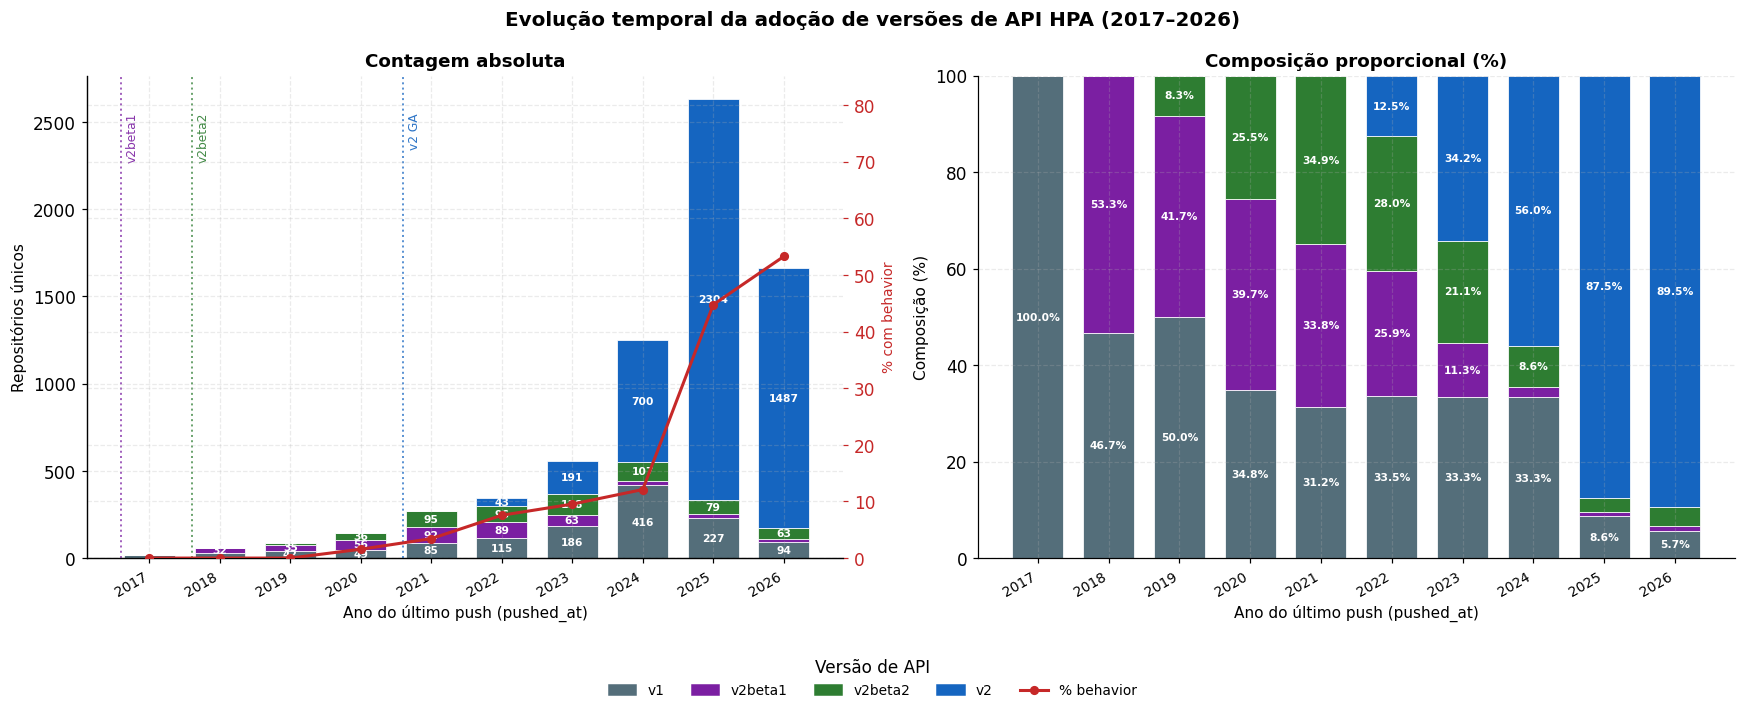

Repositórios únicos por ano x versão:
version_group   v1  v2beta1  v2beta2    v2
pushed_year                               
2017            15        0        0     0
2018            28       32        0     0
2019            42       35        7     0
2020            49       56       36     0
2021            85       92       95     0
2022           115       89       96    43
2023           186       63      118   191
2024           416       27      107   700
2025           227       24       79  2304
2026            94       18       63  1487

Composição proporcional (%):
version_group     v1  v2beta1  v2beta2    v2
pushed_year                                 
2017           100.0      0.0      0.0   0.0
2018            46.7     53.3      0.0   0.0
2019            50.0     41.7      8.3   0.0
2020            34.8     39.7     25.5   0.0
2021            31.2     33.8     34.9   0.0
2022            33.5     25.9     28.0  12.5
2023            33.3     11.3     21.1  34.2
2024       

In [14]:
# ── Análise 1: Evolução temporal — barras empilhadas com rótulos ─────────────

if not repos.empty and not p4.empty:
    import matplotlib.patches as mpatches

    _p4a = p4.copy()
    _p4a["version_group"] = _p4a["apiVersion"].apply(map_version)
    _p4a["repo_full_name"] = _p4a["Owner"].astype(str) + "/" + _p4a["Project"].astype(str)
    _p4a = _p4a.merge(repos[["repo_full_name","pushed_at"]], on="repo_full_name", how="left")
    _p4a["pushed_at"]   = pd.to_datetime(_p4a["pushed_at"], errors="coerce", utc=True)
    _p4a["pushed_year"] = _p4a["pushed_at"].dt.year

    # Repositórios únicos por (ano, version_group)  [2017–2026]
    _agg = (
        _p4a[_p4a["pushed_year"].between(2017, 2026)]
        .groupby(["pushed_year", "version_group"])["repo_full_name"]
        .nunique()
        .unstack(fill_value=0)
    )
    _order  = [v for v in ["v1","v2beta1","v2beta2","v2"] if v in _agg.columns]
    _agg    = _agg[_order]
    _totals = _agg.sum(axis=1)
    _pct    = _agg.div(_totals, axis=0).mul(100)

    # Behavior rate por ano
    _beh_rate_a1 = (
        _p4a[_p4a["pushed_year"].between(2017, 2026)]
        .groupby("pushed_year")["Has Behavior"]
        .mean().reindex(_agg.index) * 100
    )

    VERSION_COLORS_LOCAL = {"v1":"#546E7A","v2beta1":"#7B1FA2","v2beta2":"#2E7D32","v2":"#1565C0"}
    _vc = [VERSION_COLORS_LOCAL.get(v,"#999") for v in _order]

    _releases = {2016:"v1 GA", 2017:"v2beta1", 2018:"v2beta2", 2021:"v2 GA"}
    years = list(_agg.index)
    x     = np.arange(len(years))
    width = 0.72

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    def _add_vlines_a1(ax, years, max_y):
        for yr, lbl in _releases.items():
            if yr in years:
                xi = years.index(yr) - 0.4
                col_ref = VERSION_COLORS_LOCAL.get(lbl.replace(" GA","").lower(),"#607D8B")
                ax.axvline(xi, color=col_ref, linestyle=":", linewidth=1.3, alpha=0.7)
                ax.text(xi + 0.07, max_y * 0.97, lbl, fontsize=8,
                        color=col_ref, va="top", rotation=90, alpha=0.9)

    # ── Painel 1: contagem absoluta + behavior rate ───────────────────────────
    ax1 = axes[0]
    bottoms = np.zeros(len(years))
    for v, col in zip(_order, _vc):
        vals = _agg[v].values
        ax1.bar(x, vals, bottom=bottoms, color=col,
                edgecolor="white", linewidth=0.5, width=width)
        for xi, (val, bot) in enumerate(zip(vals, bottoms)):
            if val >= 30:
                ax1.text(xi, bot + val/2, f"{val:.0f}",
                         ha="center", va="center", fontsize=7,
                         color="white", fontweight="bold")
        bottoms += vals
    _add_vlines_a1(ax1, years, bottoms.max())

    axb1 = ax1.twinx()
    axb1.plot(x, _beh_rate_a1.values, color="#C62828",
              lw=2, marker="o", markersize=5, zorder=5, label="% behavior")
    axb1.set_ylabel("% com behavior", color="#C62828", fontsize=9)
    axb1.tick_params(axis="y", colors="#C62828")
    axb1.set_ylim(0, max(_beh_rate_a1.dropna().max() * 1.6, 15))
    axb1.spines["top"].set_visible(False)

    ax1.set_xticks(x)
    ax1.set_xticklabels([str(y) for y in years], rotation=30, ha="right", fontsize=9)
    ax1.set_xlabel("Ano do último push (pushed_at)", fontsize=10)
    ax1.set_ylabel("Repositórios únicos", fontsize=10)
    ax1.set_title("Contagem absoluta", fontweight="bold", fontsize=12)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ── Painel 2: composição proporcional ─────────────────────────────────────
    ax2 = axes[1]
    bottoms = np.zeros(len(years))
    for v, col in zip(_order, _vc):
        vals = _pct[v].values
        ax2.bar(x, vals, bottom=bottoms, color=col,
                edgecolor="white", linewidth=0.5, width=width)
        for xi, (val, bot) in enumerate(zip(vals, bottoms)):
            if val >= 5.0:
                ax2.text(xi, bot + val/2, f"{val:.1f}%",
                         ha="center", va="center", fontsize=7,
                         color="white", fontweight="bold")
        bottoms += vals

    ax2.set_xticks(x)
    ax2.set_xticklabels([str(y) for y in years], rotation=30, ha="right", fontsize=9)
    ax2.set_xlabel("Ano do último push (pushed_at)", fontsize=10)
    ax2.set_ylabel("Composição (%)", fontsize=10)
    ax2.set_ylim(0, 100)
    ax2.set_title("Composição proporcional (%)", fontweight="bold", fontsize=12)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # ── Legenda única externa, abaixo dos gráficos ────────────────────────────
    _legend_patches = [mpatches.Patch(color=VERSION_COLORS_LOCAL.get(v,"#999"), label=v)
                       for v in _order]
    _legend_patches.append(
        plt.Line2D([0],[0], color="#C62828", lw=2, marker="o", markersize=5, label="% behavior")
    )
    fig.legend(handles=_legend_patches, title="Versão de API",
               loc="lower center", ncol=len(_legend_patches),
               bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)

    plt.suptitle(
        "Evolução temporal da adoção de versões de API HPA (2017–2026)",
        fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    savefig("analysis_version_adoption.png")
    plt.show()

    # ── Sumário numérico ──────────────────────────────────────────────────────
    print("Repositórios únicos por ano x versão:")
    print(_agg.to_string())
    print()
    print("Composição proporcional (%):")
    print(_pct.round(1).to_string())
    print()
    print(f"Total de repos no intervalo 2017–2026: {_totals.sum():,.0f}")
    _v2_first = _pct[_pct.get("v2", pd.Series(0, index=_pct.index)) > 50]
    print(f"v2 ultrapassa 50% pela primeira vez em: {_v2_first.index[0] if len(_v2_first) else 'N/A'}")
else:
    print("Dados insuficientes para Análise 1.")


### Análise 2: RQ1: Quais métricas são utilizadas para escalonamento?

#### Contexto e motivação

A escolha da métrica é a decisão mais impactante na configuração de um HPA.
Lorido-Botran et al. (2014) identificam CPU como a métrica historicamente dominante, mas observam
que métricas de aplicação (latência, fila, RPS) oferecem melhores propriedades de controle
para workloads web modernos.

O Kubernetes v2 suporta cinco tipos de métrica:
- **`Resource`:** CPU ou memória do container; disponível sem instrumentação adicional
- **`External`:** métricas de sistemas externos (SQS, Pub/Sub, Prometheus Adapter)
- **`Pods`:** métrica agregada por pod, reportada pela própria aplicação
- **`Object`:** métrica de um objeto Kubernetes (ex: Ingress, Service)
- **`ContainerResource`:** recurso de um container específico dentro do pod

#### Design do gráfico

- **Painel esquerdo:** barras horizontais com escala log; rótulos mostram contagem e percentagem.
  A escala log é necessária pois `resource` domina por ~90× os demais tipos.
- **Painel direito:** top-15 nomes de métrica para os tipos `External` e `Pods` em escala linear.

Salvo: plots/analysis_metric_types.png


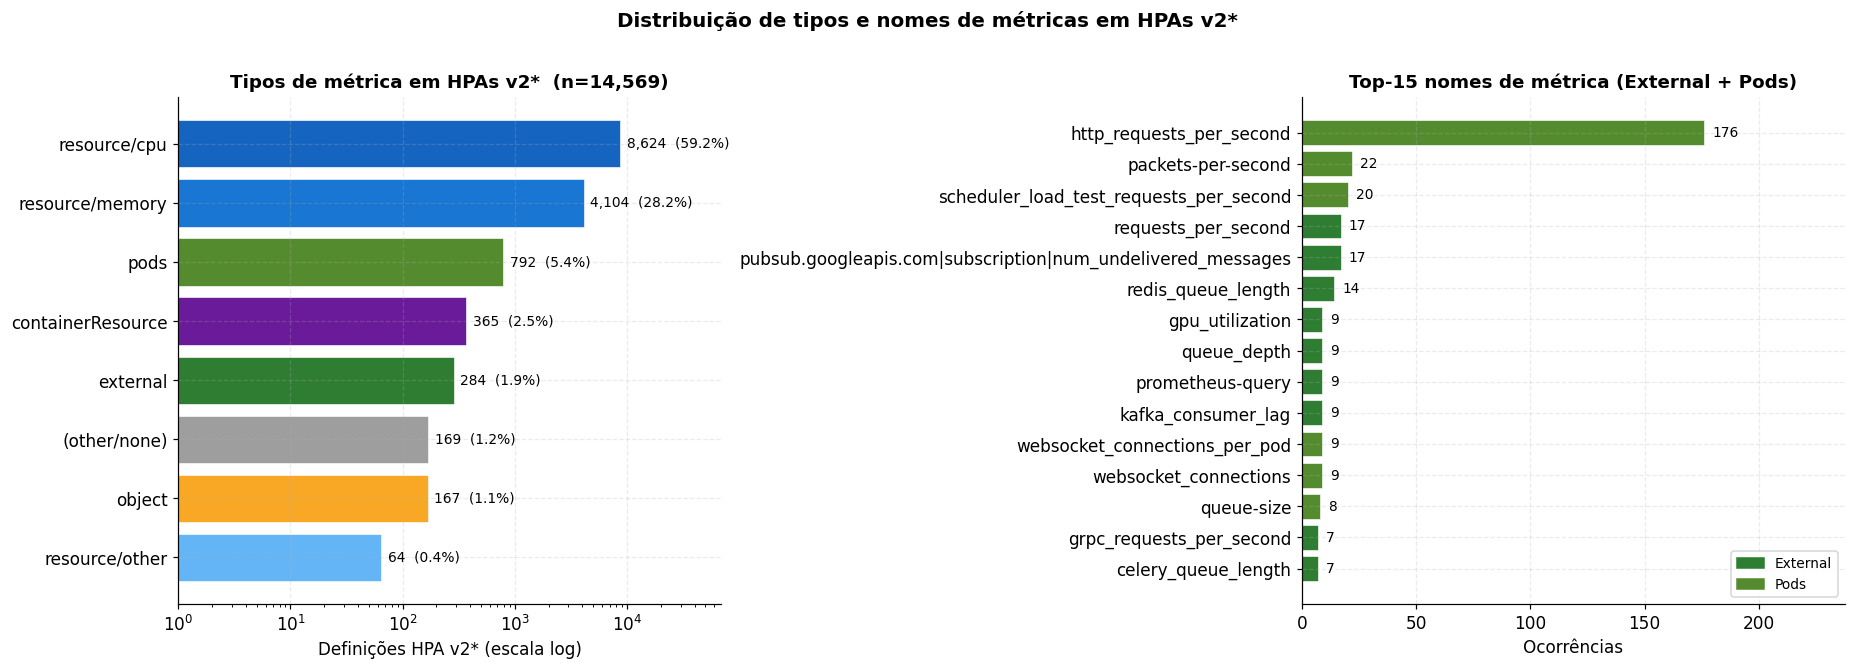

Total definições v2*: 14,569
  resource/cpu            : 8,624  (59.2%)
  resource/memory         : 4,104  (28.2%)
  pods                    : 792  (5.4%)
  containerResource       : 365  (2.5%)
  external                : 284  (1.9%)
  (other/none)            : 169  (1.2%)
  object                  : 167  (1.1%)
  resource/other          : 64  (0.4%)


In [15]:
# ── Análise 2: Tipos e nomes de métrica ──────────────────────────────────────

if not p4.empty:
    _p4b = p4[p4["apiVersion"].astype(str).str.contains("v2", na=False)].copy()
    _n_v2 = len(_p4b)

    # Grupo de tipo normalizado
    def _norm_mtype(row):
        mt = str(row.get("Metric Type","")).strip().lower()
        mn = str(row.get("Metric Name","")).strip().lower()
        if mt in ("resource","recource"):
            if mn == "cpu":    return "resource/cpu"
            if mn == "memory": return "resource/memory"
            return "resource/other"
        if mt == "containerresource": return "containerResource"
        if mt in ("pods","object","external"): return mt
        return "(other/none)"

    _p4b["mt_group"] = _p4b.apply(_norm_mtype, axis=1)
    _mt = _p4b["mt_group"].value_counts().sort_values()

    _TYPE_COLORS = {
        "resource/cpu":    "#1565C0",
        "resource/memory": "#1976D2",
        "resource/other":  "#64B5F6",
        "external":        "#2E7D32",
        "pods":            "#558B2F",
        "object":          "#F9A825",
        "containerResource":"#6A1B9A",
        "(other/none)":    "#9E9E9E",
    }

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    # ── Painel 1: barras horizontais log ─────────────────────────────────
    cols = [_TYPE_COLORS.get(k,"#BDBDBD") for k in _mt.index]
    bars = axes[0].barh(_mt.index, _mt.values, color=cols,
                        edgecolor="white", linewidth=0.4)
    for bar, val in zip(bars, _mt.values):
        pct = val / _n_v2 * 100
        axes[0].text(bar.get_width() * 1.15,
                     bar.get_y() + bar.get_height()/2,
                     f"{val:,}  ({pct:.1f}%)",
                     va="center", ha="left", fontsize=9)
    axes[0].set_xscale("log")
    axes[0].set_xlim(1, _mt.max() * 8)
    axes[0].set_xlabel("Definições HPA v2* (escala log)")
    axes[0].set_title(f"Tipos de métrica em HPAs v2*  (n={_n_v2:,})",
                      fontweight="bold", fontsize=12)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Painel 2: top nomes para External e Pods ─────────────────────────
    import matplotlib.patches as mpatches
    _ext_pods = _p4b[_p4b["Metric Type"].str.lower().isin(["external","pods"])].copy()
    if not _ext_pods.empty:
        _top_names = (_ext_pods["Metric Name"].dropna().value_counts().head(15).sort_values())
        _ext_set   = set(_p4b[_p4b["Metric Type"].str.lower()=="external"]["Metric Name"].dropna())
        _nc_colors = ["#2E7D32" if nm in _ext_set else "#558B2F"
                      for nm in _top_names.index]
        bars2 = axes[1].barh(_top_names.index.astype(str), _top_names.values,
                             color=_nc_colors, edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars2, _top_names.values):
            axes[1].text(bar.get_width() + _top_names.max()*0.02,
                         bar.get_y()+bar.get_height()/2,
                         str(val), va="center", fontsize=9)
        axes[1].set_xlim(0, _top_names.max() * 1.35)
        axes[1].set_xlabel("Ocorrências")
        axes[1].set_title("Top-15 nomes de métrica (External + Pods)",
                          fontweight="bold", fontsize=12)
        axes[1].legend(handles=[mpatches.Patch(color="#2E7D32",label="External"),
                                 mpatches.Patch(color="#558B2F",label="Pods")],
                       fontsize=9, loc="lower right")
        axes[1].spines["top"].set_visible(False)
        axes[1].spines["right"].set_visible(False)

    plt.suptitle("Distribuição de tipos e nomes de métricas em HPAs v2*",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("analysis_metric_types.png")
    plt.show()

    print(f"Total definições v2*: {_n_v2:,}")
    for mt, cnt in _mt.sort_values(ascending=False).items():
        print(f"  {mt:<24}: {cnt:,}  ({cnt/_n_v2*100:.1f}%)")
else:
    print("Dados insuficientes para Análise 2.")

### Análise 3: RQ1: Como os parâmetros de réplicas são configurados?

#### Contexto e motivação

`minReplicas` e `maxReplicas` definem o intervalo dentro do qual o HPA pode operar.
A distribuição desses valores revela se as configurações são calibradas ou copiadas de templates:

- **`minReplicas = 1`** é o default do Kubernetes quando o campo é omitido. Pode ser intencional
  (serviço tolerante a cold start) ou simplesmente o default não revisado.
- **Round numbers** em `maxReplicas` (5, 10, 20, 50, 100) sugerem escolha arbitrária em vez de
  calibração baseada em carga real ou limites de SLA (Rahman & Williams, 2019).
- **Razão `maxReplicas / minReplicas`** mede a amplitude de escalonamento.
  Uma razão pequena (≤ 2×) oferece pouca elasticidade; uma razão muito alta pode ser configuração
  excessivamente permissiva em vez de planejamento real de capacidade.

#### Design do gráfico

- **Painel 1 (minReplicas):** barras para valores 1–20 com percentagem acima de cada barra.
- **Painel 2 (maxReplicas):** histograma com os 5 valores mais frequentes anotados.
- **Painel 3 (razão max/min):** histograma com mediana marcada.

Salvo: plots/analysis_replicas.png


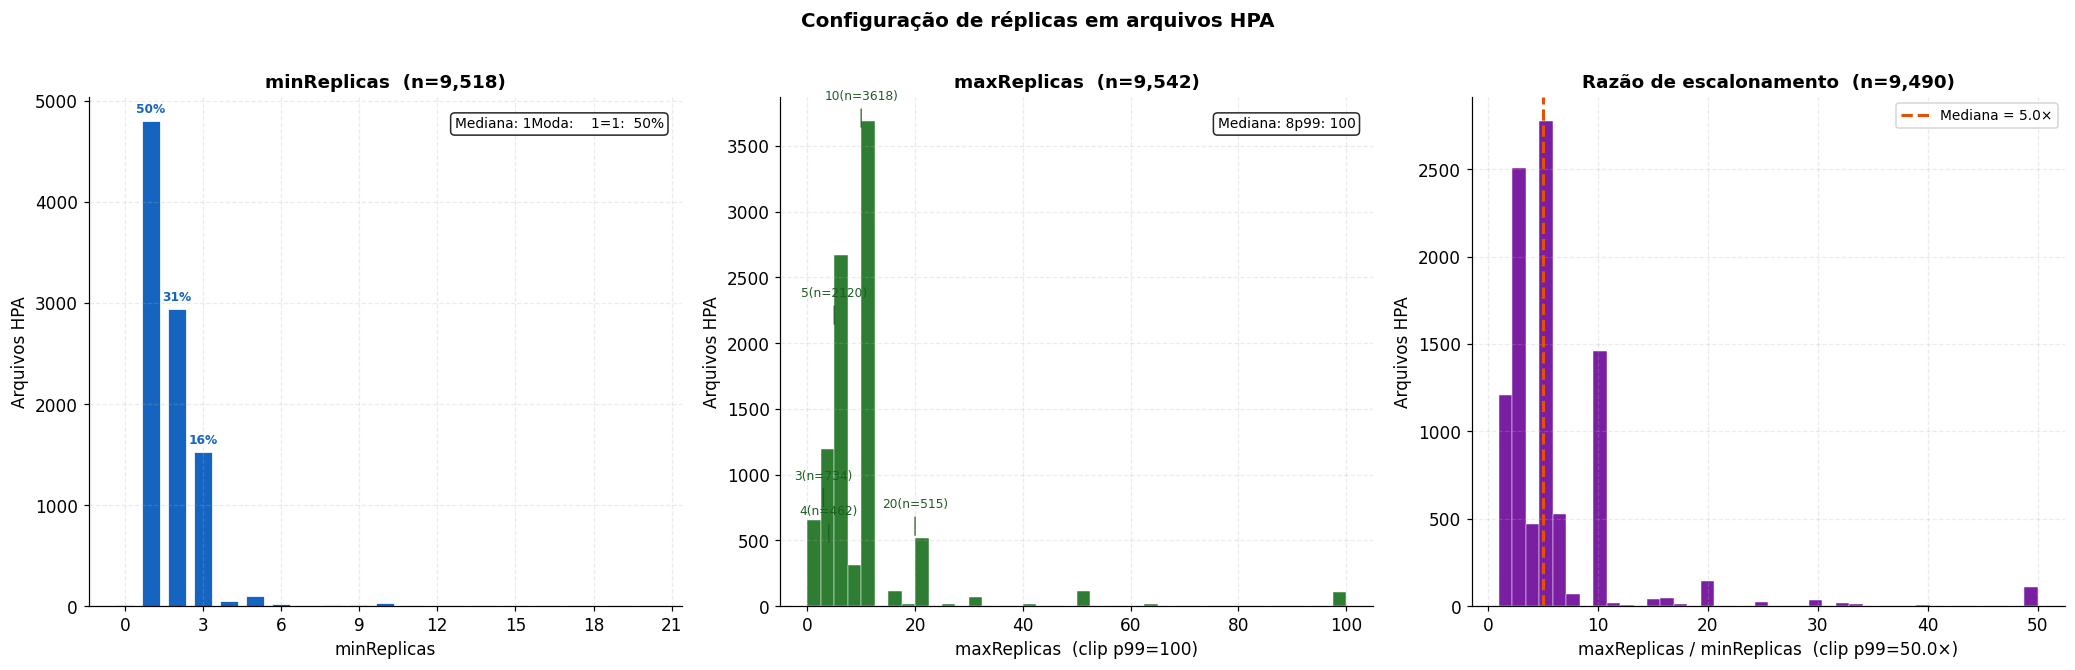

minReplicas  n=9,518  mediana=1  moda=1  p99=5
maxReplicas  n=9,542  mediana=8  p99=100
Razão        n=9,490  mediana=5.0×  p99=50.0×
minReplicas=1: 4,802 (50.5%)
Top-5 maxReplicas: {10.0: 3618, 5.0: 2120, 3.0: 734, 20.0: 515, 4.0: 462}


In [16]:
# ── Análise 3: Distribuição de minReplicas, maxReplicas e razão ───────────────

if not p4.empty:
    import matplotlib.ticker as mticker

    _p4c = p4.drop_duplicates(subset=["Owner","Project","File Path"]).copy()
    for col in ["MinReplicas","MaxReplicas"]:
        _p4c[col] = pd.to_numeric(_p4c[col], errors="coerce")
        _p4c.loc[_p4c[col].abs() > 1e5, col] = np.nan

    _min_v = _p4c["MinReplicas"].dropna()
    _max_v = _p4c["MaxReplicas"].dropna()
    _ratio = (_p4c["MaxReplicas"] / _p4c["MinReplicas"].replace(0, np.nan)).dropna()
    _ratio = _ratio[_ratio.between(1, 1000)]

    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    # ── Painel 1: minReplicas ─────────────────────────────────────────────
    _min_vc = _min_v[_min_v <= 20].value_counts().sort_index()
    _total_m = len(_min_v)
    bars = axes[0].bar(_min_vc.index.astype(int), _min_vc.values,
                       color="#1565C0", edgecolor="white", linewidth=0.5, width=0.7)
    for bar, val in zip(bars, _min_vc.values):
        pct = val / _total_m * 100
        if pct >= 1.5:
            axes[0].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height() + _min_vc.max()*0.012,
                         f"{pct:.0f}%", ha="center", va="bottom",
                         fontsize=8, color="#1565C0", fontweight="bold")
    axes[0].set_xlabel("minReplicas")
    axes[0].set_ylabel("Arquivos HPA")
    axes[0].set_title(f"minReplicas  (n={_total_m:,})", fontweight="bold", fontsize=12)
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    _box_txt = (f"Mediana: {_min_v.median():.0f}"
                f"Moda:    {_min_v.mode().iloc[0]:.0f}"
                f"=1:  {(_min_v==1).mean()*100:.0f}%")
    axes[0].text(0.97,0.96, _box_txt, transform=axes[0].transAxes,
                 ha="right", va="top", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3",facecolor="white",alpha=0.85))
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Painel 2: maxReplicas ─────────────────────────────────────────────
    _p99_max = _max_v.quantile(0.99)
    axes[1].hist(_max_v.clip(upper=_p99_max), bins=40,
                 color="#2E7D32", edgecolor="white", linewidth=0.3)
    _top5 = _max_v[_max_v <= _p99_max].value_counts().head(5)
    _ymax = axes[1].get_ylim()[1]
    for val in _top5.index:
        cnt = _top5[val]
        axes[1].annotate(
            f"{val:.0f}(n={cnt})",
            xy=(val, cnt), xytext=(val, cnt + _ymax*0.06),
            ha="center", fontsize=8, color="#1B5E20",
            arrowprops=dict(arrowstyle="-",color="#1B5E20",lw=0.8))
    axes[1].set_xlabel(f"maxReplicas  (clip p99={_p99_max:.0f})")
    axes[1].set_ylabel("Arquivos HPA")
    axes[1].set_title(f"maxReplicas  (n={len(_max_v):,})", fontweight="bold", fontsize=12)
    axes[1].text(0.97,0.96,
                 f"Mediana: {_max_v.median():.0f}p99: {_p99_max:.0f}",
                 transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3",facecolor="white",alpha=0.85))
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    # ── Painel 3: razão max/min ───────────────────────────────────────────
    _p99_r = _ratio.quantile(0.99)
    axes[2].hist(_ratio.clip(upper=_p99_r), bins=40,
                 color="#7B1FA2", edgecolor="white", linewidth=0.3)
    axes[2].axvline(_ratio.median(), color="#E65100", lw=2, linestyle="--",
                    label=f"Mediana = {_ratio.median():.1f}×")
    axes[2].set_xlabel(f"maxReplicas / minReplicas  (clip p99={_p99_r:.1f}×)")
    axes[2].set_ylabel("Arquivos HPA")
    axes[2].set_title(f"Razão de escalonamento  (n={len(_ratio):,})",
                      fontweight="bold", fontsize=12)
    axes[2].legend(fontsize=9)
    axes[2].spines["top"].set_visible(False)
    axes[2].spines["right"].set_visible(False)

    plt.suptitle("Configuração de réplicas em arquivos HPA",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("analysis_replicas.png")
    plt.show()

    print(f"minReplicas  n={_total_m:,}  mediana={_min_v.median():.0f}  moda={_min_v.mode().iloc[0]:.0f}  p99={_min_v.quantile(.99):.0f}")
    print(f"maxReplicas  n={len(_max_v):,}  mediana={_max_v.median():.0f}  p99={_p99_max:.0f}")
    print(f"Razão        n={len(_ratio):,}  mediana={_ratio.median():.1f}×  p99={_p99_r:.1f}×")
    print(f"minReplicas=1: {(_min_v==1).sum():,} ({(_min_v==1).mean()*100:.1f}%)")
    print(f"Top-5 maxReplicas: {_max_v.value_counts().head(5).to_dict()}")
else:
    print("Dados insuficientes para Análise 3.")

### Análise 4: RQ2: Atividade do repositório vs. manutenção do arquivo HPA

---

#### Qual dataset está sendo usado aqui?

Esta análise usa **`hpa_repo_aggregated.csv`** via a variável `repos`
($n = 12{,}618$ repositórios, uma linha por repositório).

É importante distinguir os três datasets do pipeline:

| Dataset | $n$ | Unidade | Usado aqui? |
|---------|-----|---------|-------------|
| `hpa_repo_aggregated.csv` (`repos`) | 12.618 | repositório | **Sim** |
| `phase4_latest.csv` (`p4`) | 9.469 arquivos únicos / 16.208 linhas métricas | arquivo HPA / métrica | Não (Análises 1–3, 5–6) |
| `phase3_file_commits_latest.csv` | 9.656 | arquivo HPA | Não diretamente |

**Por que usar os 12.618 e não os 6.846 com dados HPA?**

Esta análise mede *atividade de repositório* (campo `last_commit_age_years`),
que está disponível para todos os 12.618 repositórios, não apenas para aqueles
com arquivos HPA parseados. Incluir os repositórios sem dados de configuração HPA
válidos é correto aqui porque eles representam casos reais de projetos que usaram
HPA em algum momento (Phase 1 os encontrou) mas que podem ter removido o arquivo,
migrado para outra ferramenta, ou estão em versões incompatíveis.

O campo `last_commit_age_years` é calculado pela Phase 5 como:
- Quando disponível via Phase 3.5: idade do arquivo HPA mais recentemente modificado
- Caso contrário: `pushed_at` do repositório como proxy conservador

5.755 repositórios (45.6%) não têm `file_last_commit` real e usam o proxy.
Isso está explícito nos painéis abaixo.

---

#### Contexto e motivação

Esta é a análise central para RQ2. A hipótese nula é que repositórios ativos também
mantêm seus HPAs ativos. Se rejeitada, o padrão resultante é o que chamamos de
*maintenance drift*: o projeto evolui, mas a configuração de infraestrutura congela
no tempo.

**Distinção crítica:** `pushed_at` é atualizado por qualquer commit no repositório,
incluindo README, CI, dependências. `file_last_commit` (coletado na Phase 3.5) mede
quando o arquivo HPA *especificamente* foi tocado. Kalliamvakou et al. (2014) alertam
que métricas de nível de repositório podem mascarar padrões de nível de arquivo.
Aqui usamos `last_commit_age_years` que, quando Phase 3.5 está disponível, reflete
a idade do arquivo HPA, não do repositório inteiro.

#### Classificação de status (seguindo Coelho et al., 2019)

| Status | Critério | Interpretação |
|--------|---------|---------------|
| **Active** | `last_commit_age_years ≤ 2` | Atividade nos últimos 2 anos |
| **In-between** | `2 < last_commit_age_years ≤ 3` | Zona cinzenta, inclui repos sem dado real |
| **Outdated** | `last_commit_age_years > 3` | Inativo há mais de 3 anos |

#### Design do gráfico

- **Painel 1:** histograma de `last_commit_age_years` com limiares e mediana marcados.
- **Painel 2:** barras de status com contagens e percentuais explícitos.
- **Painel 3:** mediana de `last_commit_age_years` por quartil de `v2_ratio`, testando
  se repositórios que migraram para v2 têm HPAs mais recentes (hipótese: sim).


/tmp/ipykernel_456490/131527628.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _r4["is_active"]   = _r4["is_active"].fillna(False).astype(bool)
/tmp/ipykernel_456490/131527628.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _r4["is_outdated"] = _r4["is_outdated"].fillna(False).astype(bool)
/tmp/ipykernel_456490/131527628.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence

Salvo: plots/analysis_activity.png


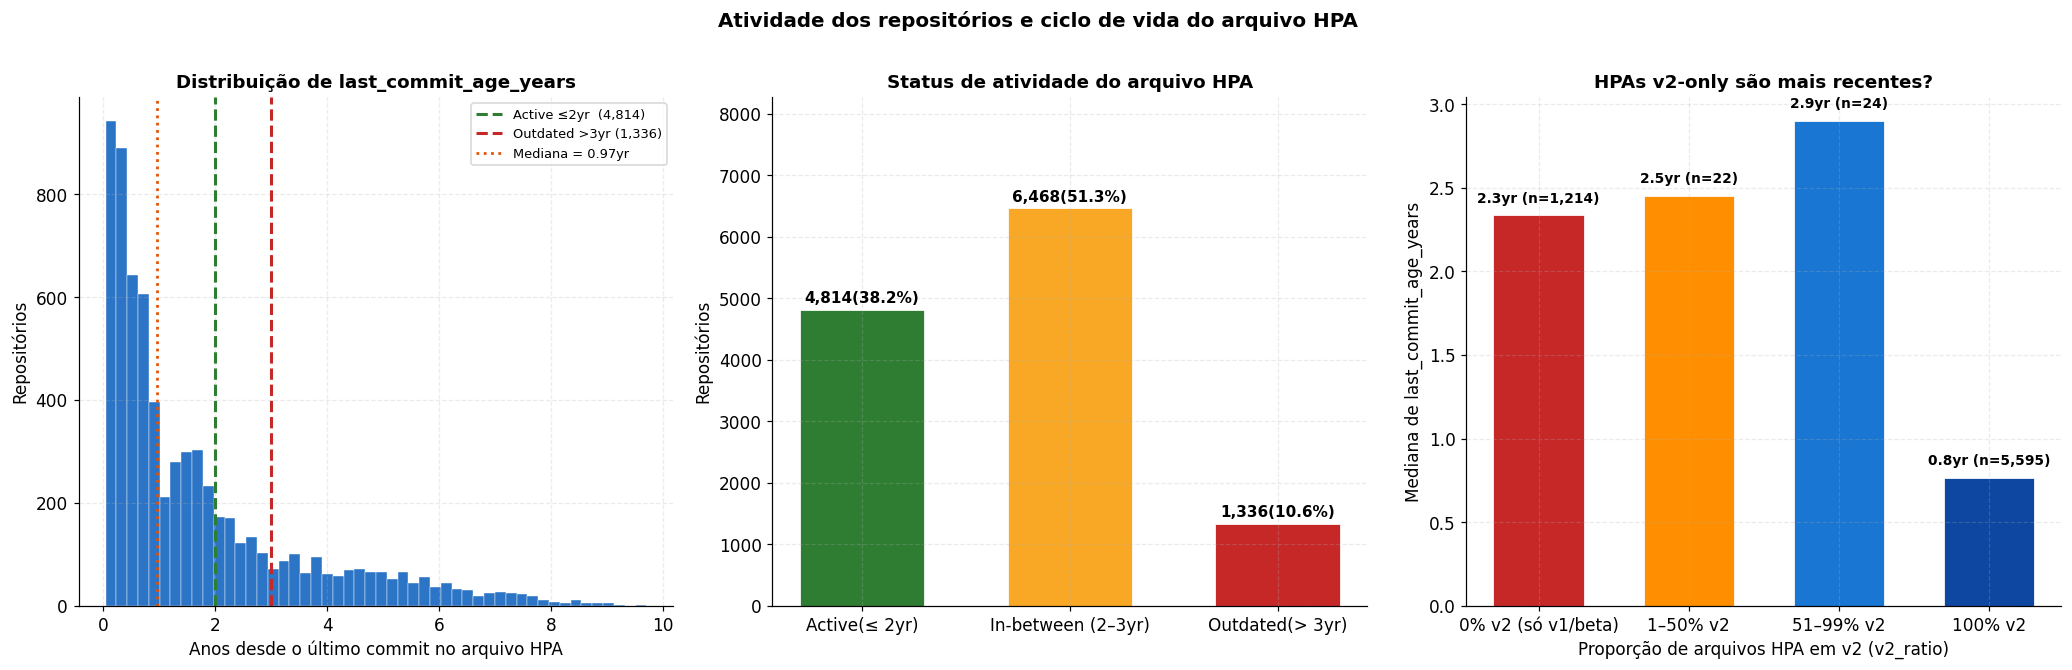

Active=4,814 (38.2%)  In-between=6,468 (51.3%)  Outdated=1,336 (10.6%)
Mediana lac=0.97yr  Média=1.73yr
Repos sem lac data: 5,755 (45.6%)


In [17]:
# ── Análise 4: Atividade dos repositórios ─────────────────────────────────────

if not repos.empty and "last_commit_age_years" in repos.columns:
    _r4 = repos.copy()
    _r4["lac"] = pd.to_numeric(_r4["last_commit_age_years"], errors="coerce")
    _r4_v = _r4.dropna(subset=["lac"])
    _r4["is_active"]   = _r4["is_active"].fillna(False).astype(bool)
    _r4["is_outdated"] = _r4["is_outdated"].fillna(False).astype(bool)

    _act  = int(_r4["is_active"].sum())
    _out  = int(_r4["is_outdated"].sum())
    _mid  = len(_r4) - _act - _out
    _tot  = len(_r4)

    STATUS_C = {"Active":"#2E7D32","In-between":"#F9A825","Outdated":"#C62828"}

    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    # ── Painel 1: histograma de last_commit_age_years ─────────────────────
    axes[0].hist(_r4_v["lac"], bins=50,
                 color="#1565C0", edgecolor="white", linewidth=0.3, alpha=0.9)
    for thr, lbl, col in [
        (2, f"Active ≤2yr  ({_act:,})", "#2E7D32"),
        (3, f"Outdated >3yr ({_out:,})", "#C62828"),
    ]:
        axes[0].axvline(thr, color=col, linestyle="--", lw=2, label=lbl)
    _med = _r4_v["lac"].median()
    axes[0].axvline(_med, color="#E65100", linestyle=":", lw=1.8,
                    label=f"Mediana = {_med:.2f}yr")
    axes[0].set_xlabel("Anos desde o último commit no arquivo HPA")
    axes[0].set_ylabel("Repositórios")
    axes[0].set_title("Distribuição de last_commit_age_years", fontweight="bold", fontsize=12)
    axes[0].legend(fontsize=8.5)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Painel 2: barras de status ────────────────────────────────────────
    cats = ["Active(≤ 2yr)", "In-between (2–3yr)", "Outdated(> 3yr)"]
    vals = [_act, _mid, _out]
    cols = [STATUS_C["Active"], STATUS_C["In-between"], STATUS_C["Outdated"]]
    bars = axes[1].bar(cats, vals, color=cols, edgecolor="white", linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + _tot*0.005,
                     f"{val:,}({val/_tot*100:.1f}%)",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[1].set_ylabel("Repositórios")
    axes[1].set_title("Status de atividade do arquivo HPA", fontweight="bold", fontsize=12)
    axes[1].set_ylim(0, max(vals)*1.28)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    # ── Painel 3: v2_ratio vs. median lag ────────────────────────────────
    _rv = _r4_v.dropna(subset=["v2_ratio"]).copy()
    _rv["v2_tier"] = pd.cut(
        _rv["v2_ratio"], bins=[-0.01, 0, 0.5, 0.99, 1.01],
        labels=["0% v2 (só v1/beta)", "1–50% v2", "51–99% v2", "100% v2"])
    _vg_data = _rv.groupby("v2_tier")["lac"].agg(["median","count"])
    _tc = ["#C62828","#FF8F00","#1976D2","#0D47A1"]
    bars3 = axes[2].bar(_vg_data.index.astype(str), _vg_data["median"],
                        color=_tc, edgecolor="white", linewidth=0.5, width=0.6)
    for bar, (_, row) in zip(bars3, _vg_data.iterrows()):
        axes[2].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.06,
                     f"{row['median']:.1f}yr (n={int(row['count']):,})",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[2].set_xlabel("Proporção de arquivos HPA em v2 (v2_ratio)")
    axes[2].set_ylabel("Mediana de last_commit_age_years")
    axes[2].set_title("HPAs v2-only são mais recentes?", fontweight="bold", fontsize=12)
    axes[2].spines["top"].set_visible(False)
    axes[2].spines["right"].set_visible(False)

    plt.suptitle("Atividade dos repositórios e ciclo de vida do arquivo HPA",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("analysis_activity.png")
    plt.show()

    print(f"Active={_act:,} ({_act/_tot*100:.1f}%)  In-between={_mid:,} ({_mid/_tot*100:.1f}%)  Outdated={_out:,} ({_out/_tot*100:.1f}%)")
    print(f"Mediana lac={_r4_v['lac'].median():.2f}yr  Média={_r4_v['lac'].mean():.2f}yr")
    print(f"Repos sem lac data: {_r4['lac'].isna().sum():,} ({_r4['lac'].isna().mean()*100:.1f}%)")
else:
    print("Dados insuficientes para Análise 4.")

### Análise 5: RQ1: Adoção do bloco `behavior`

#### Contexto e motivação

O bloco `spec.behavior` (disponível desde `v2beta2`) permite controlar separadamente políticas
de scale-up e scale-down, com janelas de estabilização e limites de taxa.
Configurar `behavior` requer que o operador tenha observado o comportamento do serviço sob
carga variável. É, portanto, um indicador de maturidade operacional mais confiável do que a
simples escolha de versão de API (Lorido-Botran et al., 2014).

#### Hipóteses
- **H1 (versão):** projetos com `autoscaling/v2` GA têm maior adoção de `behavior`
  do que `v2beta2`, pois o GA aumentou a visibilidade da feature.
- **H2 (popularidade):** projetos com mais estrelas adotam `behavior` com mais frequência, projetos mais maduros e com mais usuários tendem a operar em produção com requisitos mais rigorosos.

#### Design do gráfico

- **Painel 1:** % de HPAs com `behavior` por version group, com anotações de contagem total.
- **Painel 2:** distribuição de estrelas com e sem `behavior` em escala log, com medianas anotadas.

Salvo: plots/analysis_behavior.png


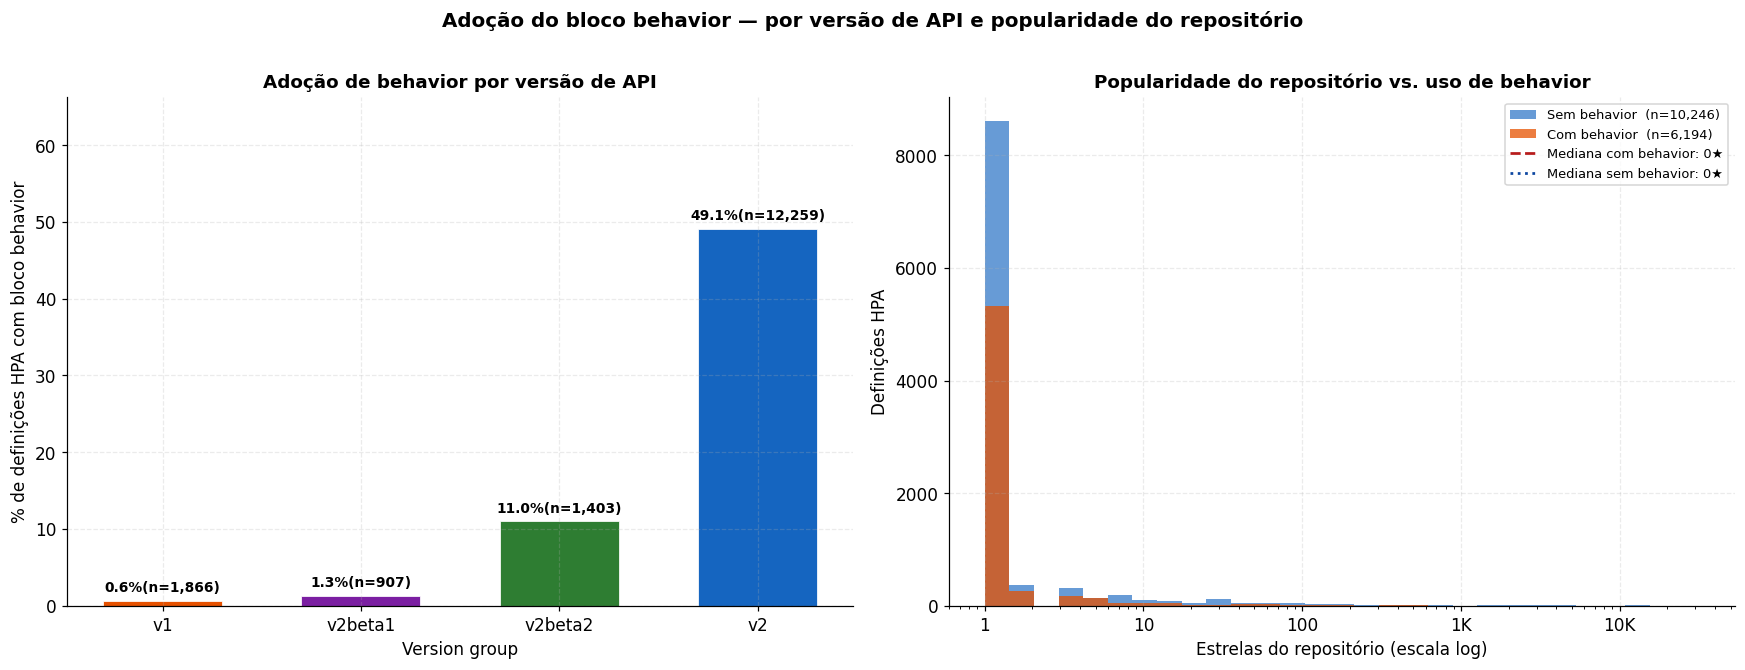

Has Behavior=True: 6,194 (37.7%)

Taxa por versão:
  v1        : 0.6%  (n=1,866)
  v2beta1   : 1.3%  (n=907)
  v2beta2   : 11.0%  (n=1,403)
  v2        : 49.1%  (n=12,259)


In [18]:
# ── Análise 5: Adoção do bloco behavior ──────────────────────────────────────

if not repos.empty and not p4.empty:
    _p4e = p4.copy()
    _p4e["version_group"] = _p4e["apiVersion"].apply(map_version)
    _p4e["repo_full_name"] = _p4e["Owner"].astype(str) + "/" + _p4e["Project"].astype(str)
    _p4e = _p4e.merge(repos[["repo_full_name","stargazers_count"]], on="repo_full_name", how="left")
    _p4e["Has Behavior"] = _p4e["Has Behavior"].fillna(False).astype(bool)

    _beh_rate = (_p4e.groupby("version_group")["Has Behavior"]
                 .agg(["sum","count"])
                 .rename(columns={"sum":"with_beh","count":"total"}))
    _beh_rate["pct"] = _beh_rate["with_beh"] / _beh_rate["total"] * 100
    _vord = [v for v in ["v1","v2beta1","v2beta2","v2"] if v in _beh_rate.index]
    _beh_rate = _beh_rate.reindex(_vord)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Painel 1: % behavior por versão ──────────────────────────────────
    _bc = [VERSION_COLORS.get(v,"#999") for v in _vord]
    bars = axes[0].bar(_vord, _beh_rate["pct"], color=_bc,
                       edgecolor="white", linewidth=0.5, width=0.6)
    for bar, (vg, row) in zip(bars, _beh_rate.iterrows()):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + 0.8,
                     f"{row['pct']:.1f}%(n={int(row['total']):,})",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[0].set_xlabel("Version group")
    axes[0].set_ylabel("% de definições HPA com bloco behavior")
    axes[0].set_title("Adoção de behavior por versão de API", fontweight="bold", fontsize=12)
    axes[0].set_ylim(0, _beh_rate["pct"].max() * 1.35)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Painel 2: popularidade vs. behavior ───────────────────────────────
    if "stargazers_count" in _p4e.columns:
        _wb  = _p4e[_p4e["Has Behavior"]]["stargazers_count"].dropna()
        _wob = _p4e[~_p4e["Has Behavior"]]["stargazers_count"].dropna()
        _bins = np.logspace(0, 4.5, 30)
        axes[1].hist(_wob.clip(lower=1), bins=_bins, alpha=0.65,
                     color="#1565C0", label=f"Sem behavior  (n={len(_wob):,})")
        axes[1].hist(_wb.clip(lower=1),  bins=_bins, alpha=0.75,
                     color="#E65100", label=f"Com behavior  (n={len(_wb):,})")
        _med_wb  = _wb.median()
        _med_wob = _wob.median()
        axes[1].axvline(_med_wb,  color="#B71C1C", lw=1.8, linestyle="--",
                        label=f"Mediana com behavior: {_med_wb:.0f}★")
        axes[1].axvline(_med_wob, color="#0D47A1", lw=1.8, linestyle=":",
                        label=f"Mediana sem behavior: {_med_wob:.0f}★")
        axes[1].set_xscale("log")
        axes[1].set_xticks([1,10,100,1000,10000])
        axes[1].set_xticklabels(["1","10","100","1K","10K"])
        axes[1].set_xlabel("Estrelas do repositório (escala log)")
        axes[1].set_ylabel("Definições HPA")
        axes[1].set_title("Popularidade do repositório vs. uso de behavior",
                          fontweight="bold", fontsize=12)
        axes[1].legend(fontsize=8.5, loc="upper right")
        axes[1].spines["top"].set_visible(False)
        axes[1].spines["right"].set_visible(False)

    plt.suptitle("Adoção do bloco behavior — por versão de API e popularidade do repositório",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("analysis_behavior.png")
    plt.show()

    _tot_beh = int(p4["Has Behavior"].fillna(False).sum())
    print(f"Has Behavior=True: {_tot_beh:,} ({_tot_beh/len(p4)*100:.1f}%)")
    print("\nTaxa por versão:")
    for vg_name, row in _beh_rate.iterrows():
        print(f"  {vg_name:<10}: {row['pct']:.1f}%  (n={int(row['total']):,})")
else:
    print("Dados insuficientes para Análise 5.")

### Análise 6: RQ1: Calibração dos target values

#### Contexto e motivação

O `Target Value` de um HPA determina o limiar que aciona o escalonamento. Para `resource/cpu`,
o valor mais difundido em toda a documentação oficial do Kubernetes, tutoriais e exemplos é **80%**.
Este valor não tem embasamento empírico para um serviço específico, é uma regra de thumb.

Rahman & Williams (2019) identificam valores hardcoded sem justificativa como um dos anti-padrões
mais comuns em scripts de configuração IaC. Para HPAs, um target pode ser:

- **Conservador demais** para serviços com custo de pod alto (sub-utiliza recursos)
- **Agressivo demais** para serviços com custo de cold start alto (escala tarde demais)

#### Questão empírica

Quantos HPAs usam exatamente o target default de 80%? E qual é a distribuição real?
Se o modo for 80%, indica que a maioria vem de cópia de documentação.
Se houver diversidade de valores, indica calibração intencional.

#### Design do gráfico

- **Painel 1:** histograma de CPU target values, com 80% destacado em laranja.
- **Painel 2:** box plots por metric type (Resource/CPU, Resource/Memory, outros).
- **Painel 3:** taxa de `behavior` por número de arquivos HPA no repositório (proxy de maturidade).

Salvo: plots/analysis_target_calibration.png


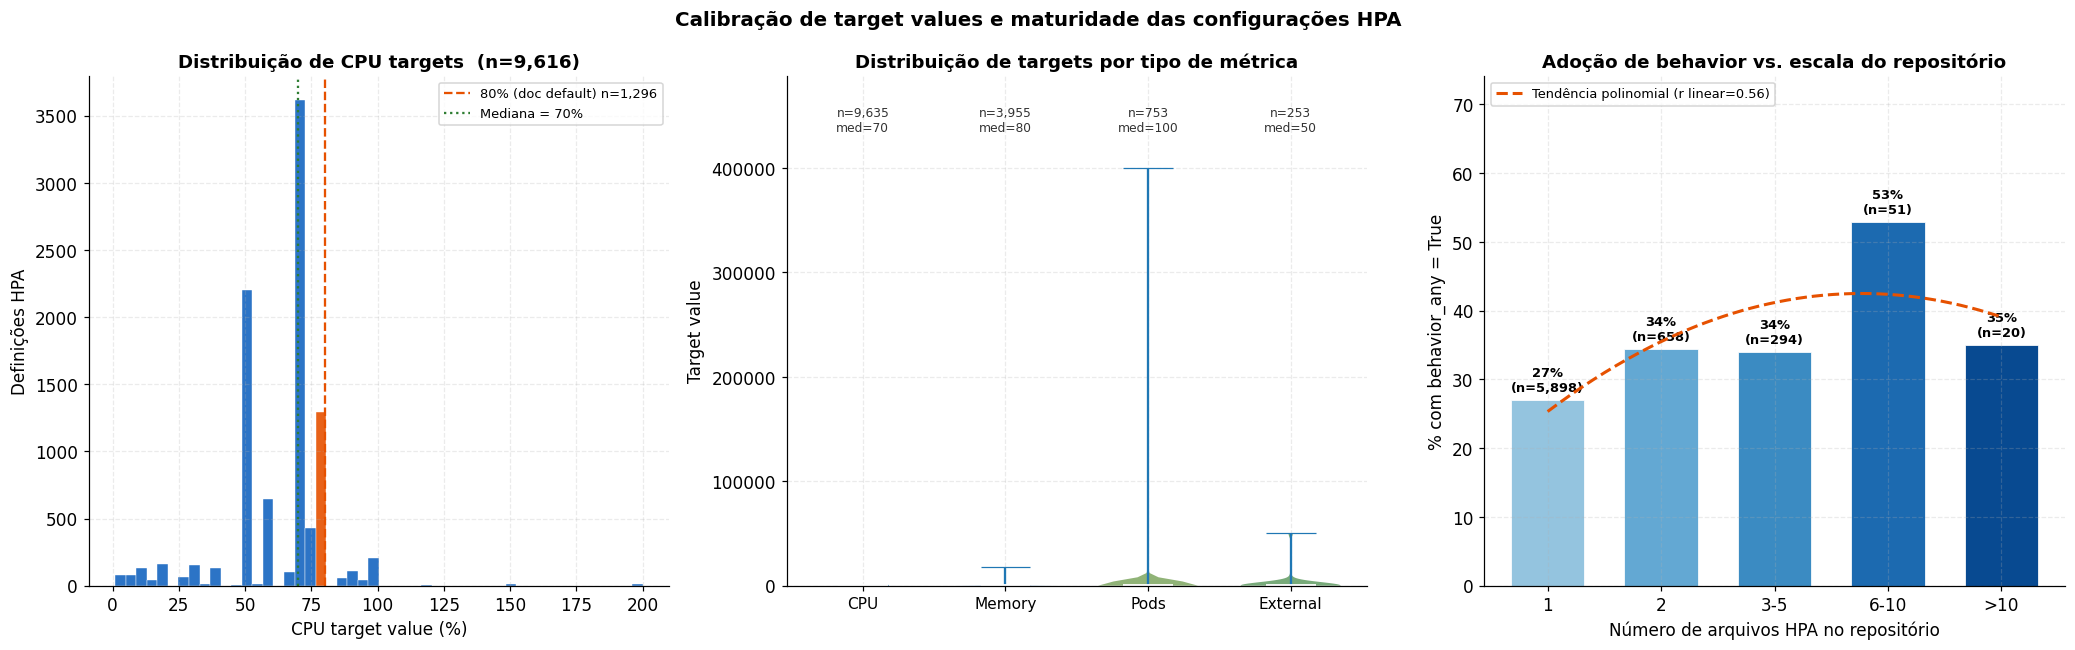

CPU targets  n=9,616  mediana=70  moda=70
  =80: 1,296  (13.5%)
  =70: 3,615  (37.6%)
  =50: 2,202  (22.9%)


In [19]:
# ── Análise 6: Calibração dos target values ───────────────────────────────────
# Dataset: phase4_latest.csv (p4) — 16,208 linhas de métrica
# Repos: hpa_repo_aggregated.csv (repos) — para hpa_files_count e behavior_any

from scipy import stats as scipy_stats

if not p4.empty:
    _p4f = p4.copy()
    _p4f["target_value"] = pd.to_numeric(_p4f["Target Value"], errors="coerce")
    _p4f["version_group"] = _p4f["apiVersion"].apply(map_version)
    _p4f["repo_full_name"] = _p4f["Owner"].astype(str) + "/" + _p4f["Project"].astype(str)
    _p4f["metric_norm"] = _p4f["Metric Type"].fillna("").str.strip().str.lower()
    _p4f["metric_name_norm"] = _p4f["Metric Name"].fillna("").str.strip().str.lower()

    if not repos.empty:
        _p4f = _p4f.merge(
            repos[["repo_full_name","hpa_files_count","behavior_any","stargazers_count"]],
            on="repo_full_name", how="left")

    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    # ── Painel 1: CPU target value histogram ─────────────────────────────
    _cpu_tv = _p4f[
        (_p4f["metric_norm"].isin(["resource","recource"])) &
        (_p4f["metric_name_norm"] == "cpu")
    ]["target_value"].dropna()
    _cpu_sane = _cpu_tv[(_cpu_tv >= 1) & (_cpu_tv <= 200)]

    counts, edges, patches = axes[0].hist(
        _cpu_sane, bins=50,
        color="#1565C0", edgecolor="white", linewidth=0.3, alpha=0.9)
    for patch, left, right in zip(patches, edges[:-1], edges[1:]):
        if left <= 80 < right:
            patch.set_facecolor("#E65100")
    axes[0].axvline(80, color="#E65100", lw=1.5, linestyle="--",
                    label=f"80% (doc default) n={int((abs(_cpu_sane-80)<0.5).sum()):,}")
    axes[0].axvline(_cpu_sane.median(), color="#2E7D32", lw=1.5, linestyle=":",
                    label=f"Mediana = {_cpu_sane.median():.0f}%")
    axes[0].set_xlabel("CPU target value (%)")
    axes[0].set_ylabel("Definições HPA")
    axes[0].set_title(f"Distribuição de CPU targets  (n={len(_cpu_sane):,})",
                      fontweight="bold", fontsize=12)
    axes[0].legend(fontsize=8.5)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # ── Painel 2: violin por tipo de métrica (substitui boxplot) ──────────
    # Violins mostram distribuição; n= no topo de cada violin
    _vln_data = {}
    _vln_colors = {"CPU":"#1565C0","Memory":"#1976D2","Pods":"#558B2F","External":"#2E7D32"}
    for mt_label, mt_filter in [
        ("CPU",     lambda d: d[(d["metric_norm"].isin(["resource","recource"])) & (d["metric_name_norm"]=="cpu")]),
        ("Memory",  lambda d: d[(d["metric_norm"].isin(["resource","recource"])) & (d["metric_name_norm"]=="memory")]),
        ("Pods",    lambda d: d[d["metric_norm"]=="pods"]),
        ("External",lambda d: d[d["metric_norm"]=="external"]),
    ]:
        sub = mt_filter(_p4f)["target_value"].dropna()
        sub = sub[(sub > 0) & (sub < 1e6)]
        if len(sub) >= 5:
            _vln_data[mt_label] = sub.values

    if _vln_data:
        positions = range(1, len(_vln_data)+1)
        vp = axes[1].violinplot(list(_vln_data.values()),
                                positions=list(positions),
                                showmedians=True, showextrema=True, widths=0.7)
        for body, col in zip(vp["bodies"], _vln_colors.values()):
            body.set_facecolor(col); body.set_alpha(0.65)
        vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2.5)
        vp["cmins"].set_linewidth(0.8); vp["cmaxes"].set_linewidth(0.8)

        # Rótulos de n= posicionados ACIMA do violin, fora da área dos dados
        _ymax = axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 1 else max(v.max() for v in _vln_data.values()) * 1.3
        for xi, (label, vals) in zip(positions, _vln_data.items()):
            axes[1].text(xi, max(v.max() for v in _vln_data.values()) * 1.08,
                         f"n={len(vals):,}\nmed={np.median(vals):.0f}",
                         ha="center", va="bottom", fontsize=8, color="#333")

        axes[1].set_xticks(list(positions))
        axes[1].set_xticklabels(list(_vln_data.keys()), fontsize=10)
        axes[1].set_ylabel("Target value")
        axes[1].set_title("Distribuição de targets por tipo de métrica",
                          fontweight="bold", fontsize=12)
        axes[1].set_ylim(0, max(v.max() for v in _vln_data.values()) * 1.22)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    # ── Painel 3: behavior por escala de hpa_files_count ─────────────────
    if "hpa_files_count" in _p4f.columns and "behavior_any" in _p4f.columns:
        _beh_scale = (
            _p4f[["repo_full_name","hpa_files_count","behavior_any"]]
            .drop_duplicates("repo_full_name")
            .dropna(subset=["hpa_files_count","behavior_any"])
            .copy()
        )
        _beh_scale["hpa_files_count"] = pd.to_numeric(_beh_scale["hpa_files_count"], errors="coerce")
        _beh_scale["behavior_any"]    = _beh_scale["behavior_any"].astype(bool)
        _beh_scale = _beh_scale[_beh_scale["hpa_files_count"] >= 1]

        _beh_scale["files_bin"] = pd.cut(
            _beh_scale["hpa_files_count"],
            bins=[0,1,2,5,10,100],
            labels=["1","2","3-5","6-10",">10"])
        _beh_by_bin = (_beh_scale.groupby("files_bin", observed=True)["behavior_any"]
                       .agg(["mean","count"]))
        _beh_by_bin["pct"] = _beh_by_bin["mean"] * 100

        _bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(_beh_by_bin)))
        bars = axes[2].bar(_beh_by_bin.index.astype(str), _beh_by_bin["pct"],
                           color=_bar_colors, edgecolor="white", linewidth=0.5, width=0.65)
        for xi, (_, row) in enumerate(_beh_by_bin.iterrows()):
            axes[2].text(xi, row["pct"] + 0.8,
                         f"{row['pct']:.0f}%\n(n={int(row['count']):,})",
                         ha="center", va="bottom", fontsize=8.5, fontweight="bold")

        # Linha de tendência polinomial (grau 2) para suavizar
        _x_fit = np.arange(len(_beh_by_bin))
        _y_fit = _beh_by_bin["pct"].values.astype(float)
        if len(_x_fit) >= 3:
            _coeffs = np.polyfit(_x_fit, _y_fit, deg=min(2, len(_x_fit)-1))
            _x_smooth = np.linspace(0, len(_beh_by_bin)-1, 200)
            _y_smooth = np.polyval(_coeffs, _x_smooth)
            _, _, _r, _, _ = scipy_stats.linregress(_x_fit, _y_fit)
            axes[2].plot(_x_smooth, _y_smooth,
                         color="#E65100", lw=2, linestyle="--", zorder=5,
                         label=f"Tendência polinomial (r linear={_r:.2f})")
            axes[2].legend(fontsize=8.5, loc="upper left")

        axes[2].set_xlabel("Número de arquivos HPA no repositório")
        axes[2].set_ylabel("% com behavior_any = True")
        axes[2].set_title("Adoção de behavior vs. escala do repositório",
                          fontweight="bold", fontsize=12)
        axes[2].set_ylim(0, _beh_by_bin["pct"].max() * 1.40)
        axes[2].spines["top"].set_visible(False)
        axes[2].spines["right"].set_visible(False)

    plt.suptitle("Calibração de target values e maturidade das configurações HPA",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    savefig("analysis_target_calibration.png")
    plt.show()

    print(f"CPU targets  n={len(_cpu_sane):,}  mediana={_cpu_sane.median():.0f}  moda={_cpu_sane.mode().iloc[0]:.0f}")
    print(f"  =80: {(abs(_cpu_sane-80)<0.5).sum():,}  ({(abs(_cpu_sane-80)<0.5).mean()*100:.1f}%)")
    print(f"  =70: {(abs(_cpu_sane-70)<0.5).sum():,}  ({(abs(_cpu_sane-70)<0.5).mean()*100:.1f}%)")
    print(f"  =50: {(abs(_cpu_sane-50)<0.5).sum():,}  ({(abs(_cpu_sane-50)<0.5).mean()*100:.1f}%)")
else:
    print("Dados insuficientes para Análise 6.")


---

## Notas de reprodutibilidade

### Pré-requisitos

```
pip install -r requirements.txt
```

Crie o arquivo `.env` na raiz do projeto com seu token do GitHub:

```
GITHUB_TOKEN="ghp_xxxxxxxxxxxxxxxxxxxx"
```

O token precisa do escopo `public_repo` (leitura). Nenhum escopo de escrita é necessário.

### Ordem de execução obrigatória

As fases devem ser executadas sequencialmente. Cada fase lê os CSVs da fase anterior.

```
1_mine_hpa_usage.ipynb
  ├── Phase 1  → data/partial_results/*-phase1.csv
  ├── Phase 2  → data/partial_results/*-phase2.csv
  ├── Phase 3  → data/phase3_latest.csv
  ├── Phase 3.5→ data/phase3_file_commits_latest.csv   (opcional, mas recomendada)
  ├── Phase 4  → data/phase4_latest.csv
  ├── Phase 5  → data/hpa_repo_aggregated.csv           ← ponto de entrada dos outros notebooks
  └── Phase 6  → data/phase6_commit_timeline_latest.csv (opcional, habilita Seção 11 do classify)

2_classify_hpa.ipynb   (requer phase3, phase4, hpa_repo_aggregated)
3_msr_repository_analysis.ipynb  (requer phase4, hpa_repo_aggregated)
```

### Comportamento de retomada

Cada fase verifica se seus CSVs de saída já existem antes de executar. Re-executar uma célula de fase não refaz o trabalho já feito, apenas coleta os itens faltantes. O cache em `data/.cache/` evita chamadas de API repetidas mesmo que os CSVs intermediários sejam apagados.

### Tempo estimado de execução (primeira vez, sem cache)

| Fase | Chamadas de API | Tempo estimado |
|---|---|---|
| Phase 1 | ~4.600 (46 shards × 100/pág × 1 pág) | 15–30 min |
| Phase 2 | ~200 (GraphQL batch de 50) | 5–10 min |
| Phase 3 | ~10.000 (1/arquivo) | 2–3 h |
| Phase 3.5 | ~10.000 (1/arquivo) | 2–3 h |
| Phase 4 | 0 (reutiliza cache da Phase 3) | < 5 min |
| Phase 5 | 0 (apenas joins locais) | < 1 min |
| Phase 6 | ~13.000 (amostra de 130 repos) | 30–60 min |

### Limitações conhecidas

**Cobertura:** o GitHub Code Search retorna no máximo 1.000 resultados por query. A estratégia de shards amplia a cobertura, mas repositórios muito pequenos ou recentes podem não aparecer nos primeiros 1.000 de nenhum shard.

**Repositórios privados/deletados:** entre a Phase 1 (busca) e as fases de download, alguns repositórios podem se tornar privados ou ser deletados. Esses casos resultam em 404 na API e são marcados como `null` nos campos dependentes.

**Helm templates:** a detecção por `{{` pode gerar falsos positivos em arquivos com comentários contendo chaves duplas. O comportamento é conservador: exclui possíveis válidos para garantir que não inclui inválidos.

**`pushed_at` vs. `file_last_commit`:** sem a Phase 3.5 executada, `last_commit_age_years` em `hpa_repo_aggregated.csv` usa `pushed_at` do repositório como proxy, não a data real do arquivo HPA. A distinção é relevante para RQ2.